# Import statements

In [1]:
import pickle
import numpy as np
import pandas as pd

In [2]:
import skopt
import scipy
import sklearn
from scipy.stats import pearsonr
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
import tqdm as notebook_tqdm

In [3]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error

In [4]:
from skopt import BayesSearchCV

from skopt.space import Real, Categorical, Integer

In [5]:
import xgboost as xgb

from math import sqrt

In [6]:
import shap

/home/supadhyaya/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from xgboost import plot_importance
from matplotlib import pyplot

In [8]:
from platform import python_version

print(python_version())



3.10.12


In [9]:
print(np.__version__)

1.26.3


# Preprocessing datasets 

## Phenotype dataset

In [26]:
#Load file
phenotype = pd.read_csv("../phenotype/bbd.txt", sep='\t')

In [27]:
phenotype.head()

,Unnamed: 0,Line,LL,LW,PLH,VBN,new_line,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
0,0,s63,7.96667,5.90000,24.0667,2.00000,s63_BeiJing_2013,1,0,0,0,0,0,1,35
1,1,s64,8.56667,5.00000,27.0333,4.66667,s64_BeiJing_2013,1,0,0,0,0,0,1,35
2,2,s66,6.40000,4.53333,101.2670,4.00000,s66_BeiJing_2013,1,0,0,0,0,0,1,53
3,3,s70,10.40000,8.23333,76.3667,6.66667,s70_BeiJing_2013,1,0,0,0,0,0,1,69
4,4,s71,9.13333,6.93333,98.8000,5.66667,s71_BeiJing_2013,1,0,0,0,0,0,1,53


In [28]:
phenotype= phenotype.drop(['Unnamed: 0'], axis=1)

In [29]:
phenotype.head()

,Line,LL,LW,PLH,VBN,new_line,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
0,s63,7.96667,5.90000,24.0667,2.00000,s63_BeiJing_2013,1,0,0,0,0,0,1,35
1,s64,8.56667,5.00000,27.0333,4.66667,s64_BeiJing_2013,1,0,0,0,0,0,1,35
2,s66,6.40000,4.53333,101.2670,4.00000,s66_BeiJing_2013,1,0,0,0,0,0,1,53
3,s70,10.40000,8.23333,76.3667,6.66667,s70_BeiJing_2013,1,0,0,0,0,0,1,69
4,s71,9.13333,6.93333,98.8000,5.66667,s71_BeiJing_2013,1,0,0,0,0,0,1,53


In [30]:
phenotype.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3170 entries, 0 to 3169
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Line               3170 non-null   object 
 1   LL                 3170 non-null   float64
 2   LW                 3170 non-null   float64
 3   PLH                3170 non-null   float64
 4   VBN                3170 non-null   float64
 5   new_line           3170 non-null   object 
 6   BeiJing_2013       3170 non-null   int64  
 7   HeNan_2014         3170 non-null   int64  
 8   HeNan_2015         3170 non-null   int64  
 9   HeiLongJiang_2014  3170 non-null   int64  
 10  HeiLongJiang_2015  3170 non-null   int64  
 11  improved_cultivar  3170 non-null   int64  
 12  landrace           3170 non-null   int64  
 13  BBD                3170 non-null   int64  
dtypes: float64(4), int64(8), object(2)
memory usage: 346.8+ KB


## PCA dataset

In [33]:
#Load file
genotype = pd.read_csv('../pca_bbd/pca_bbd_raw.txt', sep=' ', header=None)

In [34]:
genotype.head()

,0,1,2,3,4,5,6,7,8,9,...,491,492,493,494,495,496,497,498,499,500
0,s63,-0.034901,0.036154,0.000695,-0.010007,-0.000814,0.018579,0.009525,-0.012036,-0.020408,...,-0.027510,-0.008367,0.024148,0.022595,-0.004854,0.007766,-0.021842,0.007906,-0.040497,0.003999
1,s64,0.012630,-0.015253,0.008432,0.044533,-0.064294,0.063312,0.017981,-0.014156,-0.040835,...,0.018936,-0.016615,-0.026148,0.028937,0.035152,0.029805,0.002569,0.033567,-0.023213,-0.029353
2,s66,-0.063739,0.047927,-0.008013,0.021293,0.022458,0.004759,0.000706,-0.007053,0.023448,...,0.026228,0.002728,0.068923,-0.024134,0.080053,-0.029368,0.007677,0.037396,-0.047216,-0.026159
3,s70,-0.069693,0.053746,-0.013704,0.000959,0.017226,-0.017455,0.024331,0.011214,0.002853,...,0.036510,-0.028901,0.020784,0.038372,-0.029239,0.011208,0.044544,0.004507,-0.013926,-0.002127
4,s71,-0.001140,0.034095,-0.034785,0.012238,-0.002233,0.033952,-0.036617,0.066924,-0.033514,...,0.012308,-0.016131,-0.025863,-0.021064,-0.002839,-0.007544,0.019314,0.002030,-0.005925,-0.013229


In [35]:
#Setting the index and naming the index column 

genotype = genotype.rename(columns={genotype.columns[0]: 'Line'})


In [36]:
genotype = genotype.reset_index().set_index('Line')
genotype.head()

,index,1,2,3,4,5,6,7,8,9,...,491,492,493,494,495,496,497,498,499,500
Line,,,,,,,,,,,,,,,,,,,,,
s63,0,-0.034901,0.036154,0.000695,-0.010007,-0.000814,0.018579,0.009525,-0.012036,-0.020408,...,-0.027510,-0.008367,0.024148,0.022595,-0.004854,0.007766,-0.021842,0.007906,-0.040497,0.003999
s64,1,0.012630,-0.015253,0.008432,0.044533,-0.064294,0.063312,0.017981,-0.014156,-0.040835,...,0.018936,-0.016615,-0.026148,0.028937,0.035152,0.029805,0.002569,0.033567,-0.023213,-0.029353
s66,2,-0.063739,0.047927,-0.008013,0.021293,0.022458,0.004759,0.000706,-0.007053,0.023448,...,0.026228,0.002728,0.068923,-0.024134,0.080053,-0.029368,0.007677,0.037396,-0.047216,-0.026159
s70,3,-0.069693,0.053746,-0.013704,0.000959,0.017226,-0.017455,0.024331,0.011214,0.002853,...,0.036510,-0.028901,0.020784,0.038372,-0.029239,0.011208,0.044544,0.004507,-0.013926,-0.002127
s71,4,-0.001140,0.034095,-0.034785,0.012238,-0.002233,0.033952,-0.036617,0.066924,-0.033514,...,0.012308,-0.016131,-0.025863,-0.021064,-0.002839,-0.007544,0.019314,0.002030,-0.005925,-0.013229


In [37]:
genotype= genotype.drop(['index'], axis=1)

In [38]:
genotype.head()

,1,2,3,4,5,6,7,8,9,10,...,491,492,493,494,495,496,497,498,499,500
Line,,,,,,,,,,,,,,,,,,,,,
s63,-0.034901,0.036154,0.000695,-0.010007,-0.000814,0.018579,0.009525,-0.012036,-0.020408,0.017118,...,-0.027510,-0.008367,0.024148,0.022595,-0.004854,0.007766,-0.021842,0.007906,-0.040497,0.003999
s64,0.012630,-0.015253,0.008432,0.044533,-0.064294,0.063312,0.017981,-0.014156,-0.040835,0.004999,...,0.018936,-0.016615,-0.026148,0.028937,0.035152,0.029805,0.002569,0.033567,-0.023213,-0.029353
s66,-0.063739,0.047927,-0.008013,0.021293,0.022458,0.004759,0.000706,-0.007053,0.023448,0.021674,...,0.026228,0.002728,0.068923,-0.024134,0.080053,-0.029368,0.007677,0.037396,-0.047216,-0.026159
s70,-0.069693,0.053746,-0.013704,0.000959,0.017226,-0.017455,0.024331,0.011214,0.002853,-0.026395,...,0.036510,-0.028901,0.020784,0.038372,-0.029239,0.011208,0.044544,0.004507,-0.013926,-0.002127
s71,-0.001140,0.034095,-0.034785,0.012238,-0.002233,0.033952,-0.036617,0.066924,-0.033514,0.002867,...,0.012308,-0.016131,-0.025863,-0.021064,-0.002839,-0.007544,0.019314,0.002030,-0.005925,-0.013229


In [39]:
pca_data = pd.merge(genotype, phenotype, on='Line', how='outer', indicator=False)

In [40]:
pca_data.head()

,Line,1,2,3,4,5,6,7,8,9,...,VBN,new_line,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
0,s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,...,5.66667,s100_BeiJing_2013,1,0,0,0,0,0,1,61
1,s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,...,1.80000,s100_HeNan_2014,0,1,0,0,0,0,1,37
2,s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,...,3.40000,s100_HeNan_2015,0,0,1,0,0,0,1,43
3,s101,0.003827,0.031086,0.000432,0.022844,0.012101,0.026969,-0.056540,0.067615,0.002775,...,6.33333,s101_BeiJing_2013,1,0,0,0,0,0,1,39
4,s101,0.003827,0.031086,0.000432,0.022844,0.012101,0.026969,-0.056540,0.067615,0.002775,...,4.20000,s101_HeiLongJiang_2014,0,0,0,1,0,0,1,62


In [41]:
pca_data = pca_data.reset_index().set_index('Line')
pca_data= pca_data.drop(['index'], axis=1)
pca_data.head()

,1,2,3,4,5,6,7,8,9,10,...,VBN,new_line,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,0.010999,...,5.66667,s100_BeiJing_2013,1,0,0,0,0,0,1,61
s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,0.010999,...,1.80000,s100_HeNan_2014,0,1,0,0,0,0,1,37
s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,0.010999,...,3.40000,s100_HeNan_2015,0,0,1,0,0,0,1,43
s101,0.003827,0.031086,0.000432,0.022844,0.012101,0.026969,-0.056540,0.067615,0.002775,-0.005544,...,6.33333,s101_BeiJing_2013,1,0,0,0,0,0,1,39
s101,0.003827,0.031086,0.000432,0.022844,0.012101,0.026969,-0.056540,0.067615,0.002775,-0.005544,...,4.20000,s101_HeiLongJiang_2014,0,0,0,1,0,0,1,62


In [42]:
pca_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3170 entries, s100 to s99
Columns: 513 entries, 1 to BBD
dtypes: float64(504), int64(8), object(1)
memory usage: 12.4+ MB


In [17]:
#pca_data.to_pickle("full_bbd_filtered_pca_data.pkl")
#Load file
pca_data_bbd = pd.read_pickle("full_bbd_filtered_pca_data.pkl")

In [18]:
pca_data_md = pd.read_pickle("full_md_filtered_pca_data.pkl")

In [19]:
pca_data_prt = pd.read_pickle("full_prt_filtered_pca_data.pkl")

In [27]:
pca_data_bbd= pca_data_bbd.reset_index().set_index('new_line')
pca_data_bbd.head()

,Line,1,2,3,4,5,6,7,8,9,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,...,154.7000,5.66667,1,0,0,0,0,0,1,61
s100_HeNan_2014,s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,...,130.0000,1.80000,0,1,0,0,0,0,1,37
s100_HeNan_2015,s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,...,116.0000,3.40000,0,0,1,0,0,0,1,43
s101_BeiJing_2013,s101,0.003827,0.031086,0.000432,0.022844,0.012101,0.026969,-0.056540,0.067615,0.002775,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101_HeiLongJiang_2014,s101,0.003827,0.031086,0.000432,0.022844,0.012101,0.026969,-0.056540,0.067615,0.002775,...,95.7000,4.20000,0,0,0,1,0,0,1,62


In [29]:
pca_data_md= pca_data_md.reset_index().set_index('new_line')
pca_data_md.head()

,Line,1,2,3,4,5,6,7,8,9,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,0.009706,-0.025570,-0.017809,-0.008165,0.015489,0.010409,-0.042790,0.036803,0.019702,...,154.7000,5.66667,1,0,0,0,0,0,1,155.0
s100_HeNan_2014,s100,0.009706,-0.025570,-0.017809,-0.008165,0.015489,0.010409,-0.042790,0.036803,0.019702,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s100_HeNan_2015,s100,0.009706,-0.025570,-0.017809,-0.008165,0.015489,0.010409,-0.042790,0.036803,0.019702,...,116.0000,3.40000,0,0,1,0,0,0,1,115.0
s101_BeiJing_2013,s101,0.003863,-0.032203,0.003138,-0.020876,0.015008,0.019087,-0.060578,0.067670,-0.005611,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101_HeiLongJiang_2014,s101,0.003863,-0.032203,0.003138,-0.020876,0.015008,0.019087,-0.060578,0.067670,-0.005611,...,95.7000,4.20000,0,0,0,1,0,0,1,149.0


In [30]:
pca_data_prt= pca_data_prt.reset_index().set_index('new_line')
pca_data_prt.head()

,Line,1,2,3,4,5,6,7,8,9,...,500,BBD,LL,LW,PLH,SL,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,-0.013933,0.044286,0.019097,0.016521,-0.020505,0.059868,-0.038342,-0.018080,0.052516,...,-0.056954,61.0,9.50000,6.26667,154.7000,6.784,1,0,0,340.553
s100_HeNan_2014,s100,-0.013933,0.044286,0.019097,0.016521,-0.020505,0.059868,-0.038342,-0.018080,0.052516,...,-0.056954,37.0,10.22000,7.19333,130.0000,7.126,0,1,0,358.104
s101_BeiJing_2013,s101,-0.006119,0.045892,-0.015540,0.017756,-0.011560,0.102780,-0.037069,-0.012240,-0.010494,...,-0.010386,39.0,8.93333,6.53333,52.7333,8.786,1,0,0,355.712
s101_HeiLongJiang_2014,s101,-0.006119,0.045892,-0.015540,0.017756,-0.011560,0.102780,-0.037069,-0.012240,-0.010494,...,-0.010386,62.0,14.28000,10.22000,95.7000,7.624,0,0,1,385.915
s1014_BeiJing_2013,s1014,0.096765,0.028196,-0.002583,0.022170,-0.025105,-0.001168,-0.016909,-0.089279,0.030493,...,0.000719,77.0,10.36670,7.76667,111.7330,7.474,1,0,0,366.116


In [31]:
pca_data_bbd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3170 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2015
Columns: 513 entries, Line to BBD
dtypes: float64(504), int64(8), object(1)
memory usage: 12.4+ MB


In [32]:
pca_data_md.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3063 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2015
Columns: 513 entries, Line to MD
dtypes: float64(505), int64(7), object(1)
memory usage: 12.0+ MB


In [33]:
pca_data_prt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1334 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2014
Columns: 510 entries, Line to PRT
dtypes: float64(506), int64(3), object(1)
memory usage: 5.2+ MB


In [34]:
pca_bbd = pca_data_bbd.iloc[:, 0:512]
pca_bbd.head()

,Line,1,2,3,4,5,6,7,8,9,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,...,6.26667,154.7000,5.66667,1,0,0,0,0,0,1
s100_HeNan_2014,s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s100_HeNan_2015,s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,...,4.00000,116.0000,3.40000,0,0,1,0,0,0,1
s101_BeiJing_2013,s101,0.003827,0.031086,0.000432,0.022844,0.012101,0.026969,-0.056540,0.067615,0.002775,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101_HeiLongJiang_2014,s101,0.003827,0.031086,0.000432,0.022844,0.012101,0.026969,-0.056540,0.067615,0.002775,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1


In [35]:
pca_md = pca_data_md.iloc[:, 0:512]
pca_md.head()

,Line,1,2,3,4,5,6,7,8,9,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,0.009706,-0.025570,-0.017809,-0.008165,0.015489,0.010409,-0.042790,0.036803,0.019702,...,6.26667,154.7000,5.66667,1,0,0,0,0,0,1
s100_HeNan_2014,s100,0.009706,-0.025570,-0.017809,-0.008165,0.015489,0.010409,-0.042790,0.036803,0.019702,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s100_HeNan_2015,s100,0.009706,-0.025570,-0.017809,-0.008165,0.015489,0.010409,-0.042790,0.036803,0.019702,...,4.00000,116.0000,3.40000,0,0,1,0,0,0,1
s101_BeiJing_2013,s101,0.003863,-0.032203,0.003138,-0.020876,0.015008,0.019087,-0.060578,0.067670,-0.005611,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101_HeiLongJiang_2014,s101,0.003863,-0.032203,0.003138,-0.020876,0.015008,0.019087,-0.060578,0.067670,-0.005611,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1


In [36]:
pca_prt = pca_data_prt.iloc[:, 0:509]
pca_prt.head()

,Line,1,2,3,4,5,6,7,8,9,...,499,500,BBD,LL,LW,PLH,SL,BeiJing_2013,HeNan_2014,HeiLongJiang_2014
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,-0.013933,0.044286,0.019097,0.016521,-0.020505,0.059868,-0.038342,-0.018080,0.052516,...,-0.001952,-0.056954,61.0,9.50000,6.26667,154.7000,6.784,1,0,0
s100_HeNan_2014,s100,-0.013933,0.044286,0.019097,0.016521,-0.020505,0.059868,-0.038342,-0.018080,0.052516,...,-0.001952,-0.056954,37.0,10.22000,7.19333,130.0000,7.126,0,1,0
s101_BeiJing_2013,s101,-0.006119,0.045892,-0.015540,0.017756,-0.011560,0.102780,-0.037069,-0.012240,-0.010494,...,0.014513,-0.010386,39.0,8.93333,6.53333,52.7333,8.786,1,0,0
s101_HeiLongJiang_2014,s101,-0.006119,0.045892,-0.015540,0.017756,-0.011560,0.102780,-0.037069,-0.012240,-0.010494,...,0.014513,-0.010386,62.0,14.28000,10.22000,95.7000,7.624,0,0,1
s1014_BeiJing_2013,s1014,0.096765,0.028196,-0.002583,0.022170,-0.025105,-0.001168,-0.016909,-0.089279,0.030493,...,-0.001958,0.000719,77.0,10.36670,7.76667,111.7330,7.474,1,0,0


In [37]:
bbd= pca_data_bbd.iloc[:, 512:]
bbd.head()

,BBD
new_line,
s100_BeiJing_2013,61
s100_HeNan_2014,37
s100_HeNan_2015,43
s101_BeiJing_2013,39
s101_HeiLongJiang_2014,62


In [38]:
md= pca_data_md.iloc[:, 512:]
md.head()

,MD
new_line,
s100_BeiJing_2013,155.0
s100_HeNan_2014,117.0
s100_HeNan_2015,115.0
s101_BeiJing_2013,121.0
s101_HeiLongJiang_2014,149.0


In [39]:
prt= pca_data_prt.iloc[:, 509:]
prt.head()

,PRT
new_line,
s100_BeiJing_2013,340.553
s100_HeNan_2014,358.104
s101_BeiJing_2013,355.712
s101_HeiLongJiang_2014,385.915
s1014_BeiJing_2013,366.116


## Split for training and holdout

In [40]:
X_train_b, X_holdout_b, y_train_b, y_holdout_b = train_test_split(pca_bbd, bbd, test_size=0.2, random_state=42)

In [41]:
X_train_m, X_holdout_m, y_train_m, y_holdout_m = train_test_split(pca_md, md, test_size=0.2, random_state=42)

In [42]:
X_train_p, X_holdout_p, y_train_p, y_holdout_p = train_test_split(pca_prt, prt, test_size=0.2, random_state=42)

In [54]:
X_train_p.head()

,Line,1,2,3,4,5,6,7,8,9,...,499,500,BBD,LL,LW,PLH,SL,BeiJing_2013,HeNan_2014,HeiLongJiang_2014
new_line,,,,,,,,,,,,,,,,,,,,,
s844_BeiJing_2013,s844,0.047723,0.006524,-0.007488,0.022130,-0.014157,0.003341,0.079441,-0.013310,0.042492,...,0.038248,0.004386,59.0,10.23330,7.20000,96.00,7.434,1,0,0
s754_HeiLongJiang_2014,s754,-0.019630,0.022483,-0.007358,-0.013178,0.029880,0.025408,0.003410,0.067198,0.021993,...,0.020752,-0.013267,60.0,15.69330,6.41333,66.32,5.990,0,0,1
s662_HeNan_2014,s662,-0.031979,-0.018534,0.064240,0.003042,0.009271,-0.002359,0.052673,-0.076434,-0.009891,...,-0.027761,0.072563,35.0,9.68667,6.59333,77.00,8.134,0,1,0
s449_BeiJing_2013,s449,-0.002737,0.018978,0.004156,-0.035264,0.051835,-0.043596,0.072704,0.073643,0.001918,...,0.070609,0.034234,41.0,9.20000,6.73333,73.80,7.118,1,0,0
s190_HeiLongJiang_2014,s190,0.028965,0.021948,-0.002958,-0.015534,0.015381,-0.020044,0.030427,0.068150,-0.028853,...,0.006555,-0.018785,60.0,13.10000,8.60667,49.94,7.330,0,0,1


In [55]:
X_train_p.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1067 entries, s844_BeiJing_2013 to s762_HeiLongJiang_2014
Columns: 509 entries, Line to HeiLongJiang_2014
dtypes: float64(505), int64(3), object(1)
memory usage: 4.2+ MB


In [56]:
X_holdout_p.info()

<class 'pandas.core.frame.DataFrame'>
Index: 267 entries, s625_BeiJing_2013 to s739_BeiJing_2013
Columns: 509 entries, Line to HeiLongJiang_2014
dtypes: float64(505), int64(3), object(1)
memory usage: 1.0+ MB


In [57]:
y_train_p.head()

,PRT
new_line,
s844_BeiJing_2013,367.541
s754_HeiLongJiang_2014,315.181
s662_HeNan_2014,337.968
s449_BeiJing_2013,388.594
s190_HeiLongJiang_2014,368.171


In [48]:
X_train_b.to_pickle("x_train_pca_bbd.pkl")
y_train_b.to_pickle("y_train_pca_bbd.pkl")
X_holdout_b.to_pickle("x_holdout_pca_bbd.pkl")
y_holdout_b.to_pickle("y_holdout_pca_bbd.pkl")

In [53]:
X_train_m.to_pickle("x_train_pca_md.pkl")
y_train_m.to_pickle("y_train_pca_md.pkl")
X_holdout_m.to_pickle("x_holdout_pca_md.pkl")
y_holdout_m.to_pickle("y_holdout_pca_md.pkl")

In [58]:
X_train_p.to_pickle("x_train_pca_prt.pkl")
y_train_p.to_pickle("y_train_pca_prt.pkl")
X_holdout_p.to_pickle("x_holdout_pca_prt.pkl")
y_holdout_p.to_pickle("y_holdout_pca_prt.pkl")

In [78]:
X_train_b = X_train_b.reset_index()
#X_train_b= X_train_b.drop(['index'], axis=1)
X_train_b.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
0,s2095_HeiLongJiang_2014,s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,...,10.06000,54.12,4.0,0,0,0,1,0,1,0
1,s678_HeNan_2014,s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,...,7.42000,66.00,1.6,0,1,0,0,0,1,0
2,s204_HeNan_2015,s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,...,9.45333,49.00,3.0,0,0,1,0,0,1,0
3,s640_HeNan_2015,s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,...,5.95333,90.00,0.0,0,0,1,0,0,1,0
4,s655_HeNan_2014,s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,...,6.08667,70.00,1.8,0,1,0,0,0,1,0


In [77]:
X_train_m = X_train_m.reset_index()
X_train_m.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
0,s503_BeiJing_2013,s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,...,6.60000,43.9333,5.33333,1,0,0,0,0,0,1
1,s2833_HeNan_2015,s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,...,5.54667,83.2000,1.40000,0,0,1,0,0,1,0
2,s1616_HeNan_2015,s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,...,8.32000,60.8000,3.80000,0,0,1,0,0,1,0
3,s833_HeNan_2014,s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,...,3.78000,67.0000,0.80000,0,1,0,0,0,1,0
4,s265_HeNan_2014,s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,...,7.43333,79.0000,1.00000,0,1,0,0,0,1,0


In [79]:
X_train_p = X_train_p.reset_index()
X_train_p.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,499,500,BBD,LL,LW,PLH,SL,BeiJing_2013,HeNan_2014,HeiLongJiang_2014
0,s844_BeiJing_2013,s844,0.047723,0.006524,-0.007488,0.022130,-0.014157,0.003341,0.079441,-0.013310,...,0.038248,0.004386,59.0,10.23330,7.20000,96.00,7.434,1,0,0
1,s754_HeiLongJiang_2014,s754,-0.019630,0.022483,-0.007358,-0.013178,0.029880,0.025408,0.003410,0.067198,...,0.020752,-0.013267,60.0,15.69330,6.41333,66.32,5.990,0,0,1
2,s662_HeNan_2014,s662,-0.031979,-0.018534,0.064240,0.003042,0.009271,-0.002359,0.052673,-0.076434,...,-0.027761,0.072563,35.0,9.68667,6.59333,77.00,8.134,0,1,0
3,s449_BeiJing_2013,s449,-0.002737,0.018978,0.004156,-0.035264,0.051835,-0.043596,0.072704,0.073643,...,0.070609,0.034234,41.0,9.20000,6.73333,73.80,7.118,1,0,0
4,s190_HeiLongJiang_2014,s190,0.028965,0.021948,-0.002958,-0.015534,0.015381,-0.020044,0.030427,0.068150,...,0.006555,-0.018785,60.0,13.10000,8.60667,49.94,7.330,0,0,1


In [80]:
pca_full_train_b = pd.merge(X_train_b, y_train_b, on='new_line', how='right', indicator=False)
pca_full_train_b.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
0,s2095_HeiLongJiang_2014,s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,...,54.12,4.0,0,0,0,1,0,1,0,59
1,s678_HeNan_2014,s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,...,66.00,1.6,0,1,0,0,0,1,0,41
2,s204_HeNan_2015,s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,...,49.00,3.0,0,0,1,0,0,1,0,43
3,s640_HeNan_2015,s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,...,90.00,0.0,0,0,1,0,0,1,0,42
4,s655_HeNan_2014,s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,...,70.00,1.8,0,1,0,0,0,1,0,30


In [81]:
pca_full_train_m = pd.merge(X_train_m, y_train_m, on='new_line', how='right', indicator=False)
pca_full_train_m.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
0,s503_BeiJing_2013,s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,...,43.9333,5.33333,1,0,0,0,0,0,1,113.0
1,s2833_HeNan_2015,s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,...,83.2000,1.40000,0,0,1,0,0,1,0,107.0
2,s1616_HeNan_2015,s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,...,60.8000,3.80000,0,0,1,0,0,1,0,100.0
3,s833_HeNan_2014,s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,...,67.0000,0.80000,0,1,0,0,0,1,0,103.0
4,s265_HeNan_2014,s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,...,79.0000,1.00000,0,1,0,0,0,1,0,103.0


In [82]:
pca_full_train_p = pd.merge(X_train_p, y_train_p, on='new_line', how='right', indicator=False)
pca_full_train_p.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,500,BBD,LL,LW,PLH,SL,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,PRT
0,s844_BeiJing_2013,s844,0.047723,0.006524,-0.007488,0.022130,-0.014157,0.003341,0.079441,-0.013310,...,0.004386,59.0,10.23330,7.20000,96.00,7.434,1,0,0,367.541
1,s754_HeiLongJiang_2014,s754,-0.019630,0.022483,-0.007358,-0.013178,0.029880,0.025408,0.003410,0.067198,...,-0.013267,60.0,15.69330,6.41333,66.32,5.990,0,0,1,315.181
2,s662_HeNan_2014,s662,-0.031979,-0.018534,0.064240,0.003042,0.009271,-0.002359,0.052673,-0.076434,...,0.072563,35.0,9.68667,6.59333,77.00,8.134,0,1,0,337.968
3,s449_BeiJing_2013,s449,-0.002737,0.018978,0.004156,-0.035264,0.051835,-0.043596,0.072704,0.073643,...,0.034234,41.0,9.20000,6.73333,73.80,7.118,1,0,0,388.594
4,s190_HeiLongJiang_2014,s190,0.028965,0.021948,-0.002958,-0.015534,0.015381,-0.020044,0.030427,0.068150,...,-0.018785,60.0,13.10000,8.60667,49.94,7.330,0,0,1,368.171


In [83]:
pca_full_train_b.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2536 entries, 0 to 2535
Columns: 514 entries, new_line to BBD
dtypes: float64(504), int64(8), object(2)
memory usage: 9.9+ MB


In [84]:
pca_full_train_m.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2450 entries, 0 to 2449
Columns: 514 entries, new_line to MD
dtypes: float64(505), int64(7), object(2)
memory usage: 9.6+ MB


In [85]:
pca_full_train_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Columns: 511 entries, new_line to PRT
dtypes: float64(506), int64(3), object(2)
memory usage: 4.2+ MB


In [86]:
pca_full_train_b.to_pickle("pca_full_training_bbd.pkl")
pca_full_train_m.to_pickle("pca_full_training_md.pkl")
pca_full_train_p.to_pickle("pca_full_training_prt.pkl")

In [90]:
X_holdout_b = X_holdout_b.reset_index()
#X_holdout_b= X_holdout_b.drop(['index'], axis=1)
X_holdout_b.head()


,new_line,Line,1,2,3,4,5,6,7,8,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
0,s143_HeNan_2014,s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,...,7.44000,90.0,1.00000,0,1,0,0,0,0,1
1,s525_HeNan_2015,s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,...,6.52000,200.4,1.40000,0,0,1,0,0,0,1
2,s2272_HeNan_2014,s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,...,6.72667,46.6,0.80000,0,1,0,0,0,1,0
3,s2255_HeiLongJiang_2014,s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,...,5.53333,49.8,4.66667,0,0,0,1,0,1,0
4,s1588_HeNan_2014,s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,...,6.07333,61.6,1.80000,0,1,0,0,0,1,0


In [88]:
X_holdout_m = X_holdout_m.reset_index()
X_holdout_m.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
0,s2692_HeiLongJiang_2015,s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,...,4.96600,94.8000,1.40000,0,0,0,0,1,1,0
1,s131_HeNan_2015,s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,...,6.11333,120.8000,2.80000,0,0,1,0,0,0,1
2,s272_HeNan_2014,s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,...,4.19333,60.4000,1.60000,0,1,0,0,0,1,0
3,s344_HeNan_2014,s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,...,7.30667,63.0000,1.80000,0,1,0,0,0,0,1
4,s324_BeiJing_2013,s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,...,6.93333,97.1667,4.33333,1,0,0,0,0,0,1


In [92]:
X_holdout_p = X_holdout_p.reset_index()
#X_holdout_p= X_holdout_p.drop(['index'], axis=1)
X_holdout_p.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,499,500,BBD,LL,LW,PLH,SL,BeiJing_2013,HeNan_2014,HeiLongJiang_2014
0,s625_BeiJing_2013,s625,-0.026468,0.002218,0.047288,0.021343,-0.070158,0.012411,-0.018335,0.071603,...,0.013756,-0.015567,61.0,8.7000,6.66667,67.5000,7.412,1,0,0
1,s722_BeiJing_2013,s722,-0.045996,0.024846,-0.055552,0.007956,0.019921,-0.040272,0.024809,-0.021013,...,-0.031883,0.056175,33.0,10.6000,4.33333,57.0333,7.206,1,0,0
2,s828_BeiJing_2013,s828,-0.003471,0.018158,-0.006217,-0.008056,0.055950,-0.066355,0.037500,-0.004974,...,-0.050015,0.018971,38.0,8.1000,6.36667,77.4667,7.272,1,0,0
3,s271_HeNan_2014,s271,-0.023611,0.055950,0.079366,-0.009974,-0.025017,0.045787,-0.001240,-0.040877,...,-0.052619,0.036257,30.0,9.4600,7.19333,87.0000,7.306,0,1,0
4,s231_HeNan_2014,s231,-0.013267,-0.069702,0.062598,0.020831,0.000861,0.032627,0.012150,0.019918,...,-0.003534,0.001959,50.0,12.3733,7.91333,120.0000,7.624,0,1,0


In [93]:
pca_full_holdout_b = pd.merge(X_holdout_b, y_holdout_b, on='new_line', how='right', indicator=False)
pca_full_holdout_b.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
0,s143_HeNan_2014,s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,...,90.0,1.00000,0,1,0,0,0,0,1,42
1,s525_HeNan_2015,s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,...,200.4,1.40000,0,0,1,0,0,0,1,42
2,s2272_HeNan_2014,s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,...,46.6,0.80000,0,1,0,0,0,1,0,32
3,s2255_HeiLongJiang_2014,s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,...,49.8,4.66667,0,0,0,1,0,1,0,56
4,s1588_HeNan_2014,s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,...,61.6,1.80000,0,1,0,0,0,1,0,32


In [94]:
pca_full_holdout_m = pd.merge(X_holdout_m, y_holdout_m, on='new_line', how='right', indicator=False)
pca_full_holdout_m.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
0,s2692_HeiLongJiang_2015,s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,...,94.8000,1.40000,0,0,0,0,1,1,0,117.0
1,s131_HeNan_2015,s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,...,120.8000,2.80000,0,0,1,0,0,0,1,115.0
2,s272_HeNan_2014,s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,...,60.4000,1.60000,0,1,0,0,0,1,0,100.0
3,s344_HeNan_2014,s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,...,63.0000,1.80000,0,1,0,0,0,0,1,107.0
4,s324_BeiJing_2013,s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,...,97.1667,4.33333,1,0,0,0,0,0,1,168.0


In [95]:
pca_full_holdout_p = pd.merge(X_holdout_p, y_holdout_p, on='new_line', how='right', indicator=False)
pca_full_holdout_p.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,500,BBD,LL,LW,PLH,SL,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,PRT
0,s625_BeiJing_2013,s625,-0.026468,0.002218,0.047288,0.021343,-0.070158,0.012411,-0.018335,0.071603,...,-0.015567,61.0,8.7000,6.66667,67.5000,7.412,1,0,0,336.057
1,s722_BeiJing_2013,s722,-0.045996,0.024846,-0.055552,0.007956,0.019921,-0.040272,0.024809,-0.021013,...,0.056175,33.0,10.6000,4.33333,57.0333,7.206,1,0,0,360.402
2,s828_BeiJing_2013,s828,-0.003471,0.018158,-0.006217,-0.008056,0.055950,-0.066355,0.037500,-0.004974,...,0.018971,38.0,8.1000,6.36667,77.4667,7.272,1,0,0,386.365
3,s271_HeNan_2014,s271,-0.023611,0.055950,0.079366,-0.009974,-0.025017,0.045787,-0.001240,-0.040877,...,0.036257,30.0,9.4600,7.19333,87.0000,7.306,0,1,0,358.938
4,s231_HeNan_2014,s231,-0.013267,-0.069702,0.062598,0.020831,0.000861,0.032627,0.012150,0.019918,...,0.001959,50.0,12.3733,7.91333,120.0000,7.624,0,1,0,324.506


In [96]:
pca_full_holdout_b.to_pickle("pca_full_holdout_bbd.pkl")
pca_full_holdout_m.to_pickle("pca_full_holdout_md.pkl")
pca_full_holdout_p.to_pickle("pca_full_holdout_prt.pkl")

# All functions

In [8]:
#set the parameter space for XGBoost regression
space ={'learning_rate': Real(0.01, 1.0, 'log-uniform'),
        'min_child_weight': Integer(0, 10),
        'max_depth': Integer(0, 50),
        'max_delta_step': Integer(0, 20),
        'subsample': Real(0.01, 1.0, 'uniform'),
        'colsample_bytree': Real(0.01, 1.0, 'uniform'),
        'colsample_bylevel': Real(0.01, 1.0, 'uniform'),
        'reg_lambda': Real(1e-9, 1000, 'log-uniform'),
        'reg_alpha': Real(1e-9, 1.0, 'log-uniform'),
        'gamma': Real(1e-9, 0.5, 'log-uniform'),
        'n_estimators': Integer(50, 200),
        }

#set parameter space for Random forest models
rf_space = {
    'n_estimators': Integer(50, 500),  # Number of trees
    'max_depth': Integer(3, 50),  # Maximum depth of trees
    'min_samples_split': Integer(2, 20),  # Minimum samples to split a node
    'min_samples_leaf': Integer(1, 10),  # Minimum samples per leaf node
    'max_features': Categorical(['sqrt']),  # Number of features to consider
    'bootstrap': Categorical([True]),  # Use bootstrapping
    'max_samples': Real(0.5, 1.0, 'uniform'),  # Fraction of samples used for training
}

#set parameter space for SVM models
svr_space = {
    'kernel': Categorical(['linear', 'rbf', 'poly', 'sigmoid']),
    'epsilon': Categorical([0.5, 1, 1.5, 2, 2.5, 3]),
}
  

In [9]:
#callback function to be used later which stops parameter search if it goes above 98% to save time
def on_step(optim_result):
    """
    Callback meant to view scores after
    each iteration while performing Bayesian
    Optimization in Skopt"""
    score = xgb_bayes_search.best_result_['score']
    print("best score: %s" % score)
    if score >= 0.98:
        print('Interrupting!')
        return True

In [10]:
#input training sets to find the best hyperparameters using Bayesian cross-validation for XGBoost model

def bayesian_xgb_search(X, y,space):
    """
    Perform Bayesian hyperparameter tuning for XGBoost using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        xgb.XGBRegressor: Best XGBoost model with tuned parameters.
    """
    xgbreg = xgb.XGBRegressor()
    xgb_bayes_search = BayesSearchCV(
        xgbreg, space, n_iter=50, scoring=None, n_jobs=-1,
        cv=5, verbose=1, random_state=42, n_points=12
    )

    xgb_bayes_search.fit(X, y)
    
    print("Best XGB Parameters:", xgb_bayes_search.best_params_)
    
    best_params = xgb_bayes_search.best_params_
    best_xgbreg = xgb.XGBRegressor(**best_params)

    return best_xgbreg

#TO RUN - best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

def bayesian_rfr_search(X, y,rf_space):
    """
    Perform Bayesian hyperparameter tuning for Random forest using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        RFRegressor: Best Random Forest model with tuned parameters.
    """
    rfr = RandomForestRegressor()
    rf_bayes_search = BayesSearchCV(rfr, rf_space, n_iter=32, # specify how many iterations
                                    scoring=None, n_jobs=-1, cv=5, verbose=1, random_state=42, n_points=7 # Use all CPU cores
                                   )
    
    rf_bayes_search.fit(X, y.ravel())
    
    print("Best RF Parameters:",  rf_bayes_search.best_params_)
    
    best_params = rf_bayes_search.best_params_
    best_rfreg = RandomForestRegressor(**best_params)

    return best_rfreg

#TO RUN - best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

def bayesian_svr_search(X, y, svr_space):
    """
    Perform Bayesian hyperparameter tuning for SVR using BayesSearchCV.

    Parameters:
        X (array-like): Feature set.
        y (array-like): Target variable.
        svr_space (dict): Hyperparameter search space for SVR.

    Returns:
        SVR: Best SVR model with tuned parameters.
    """
    svr = SVR()
    svr_bayes_search = BayesSearchCV(
        svr,
        svr_space,
        n_iter=10,
        scoring=None,
        n_jobs=-1,
        cv=5,
        verbose=1,
        random_state=42,
        n_points=2
    )

    svr_bayes_search.fit(X, y.ravel())
    
    print("Best SVR Parameters:", svr_bayes_search.best_params_)
    
    best_params = svr_bayes_search.best_params_
    best_svr = SVR(**best_params)

    return best_svr

#TO RUN - best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

In [11]:
#input full sets except houldout to find the best model using k-fold (10) cross validation which uses the best hyperparametres from the previous step. 

def eval_k_fold(m, x, y, k):
    #model: xgboost model, should be with the best params available
    #x: input data (eg. all samples and SNPS)
    #y: labels
    #k: number of folds for cross validation
    cv = KFold(n_splits=k,shuffle=True)
  #  fig1 = plt.figure(figsize=[12,12])

   # tprs = []
   # aucs = []
    results = []
   # mean_fpr = np.linspace(0,1,100)
    low = 100
    best = m
    i = 1
    for train,test in cv.split(x,y):
        #print(y[test])
        m.fit(x[train],y[train].ravel())
        print("fitting done. Processing fold accuracy + checking best model")
        #predictions = [round(value) for value in y_pred]
        #sees how accurate the model was when testing the test set
        all_preds = [x for x in m.predict(x[test])]
        ss = sqrt(mean_squared_error(all_preds, y[test]))
        rr = r2_score(all_preds, y[test])
        mm = np.mean(y[test])
        error_mean = ((ss/mm)*100)
        print("R^2 Value is: " + str(rr))
        print("RMSE for dataset is:" +str(ss) + "& mean of this fold is " + str(mm))
        print("this is "+ str((ss/mm)*100) + "% of the mean pheno data")
        if(error_mean < low):
            low = error_mean
            best = m
        results.append(error_mean)
        i= i+1
    print("Training Testing Accuracy: %.2f%% (%.2f%%)" % (np.mean(results), np.std(results)))
    return best

#TO RUN - best_model_xgb = eval_k_fold(model, X, y, 10) or best_model_rfr = eval_k_fold(model, X, y, 10)


In [12]:
def plot_xgb_feature_importance(best_model, X_train, top_n=20):
    """
    Computes and plots the feature importance of an XGBoost model based on Gain.

    Parameters:
        best_model (XGBRegressor): Trained XGBoost model from Kfold cross validation.
        X_train (DataFrame): Training feature set used for Kfold CV.
        top_n (int): Number of top features to display. Default is 20.

    Returns:
        DataFrame: DataFrame containing feature importance scores.
    """
    # Generate feature names
    f_names = ['f' + str(i) for i in range(len(X_train.columns))]
    my_dict = best_model.get_booster().get_score(importance_type="gain")

    # Map feature names back to original column names
    new_dict = {X_train.columns[f_names.index(key)]: value for key, value in my_dict.items()}

    # Convert to DataFrame
    df = pd.DataFrame.from_dict(new_dict, orient='index', columns=['F_Score(GAIN)'])

    # Select top N important features
    top_features = df.nlargest(top_n, "F_Score(GAIN)")

    # Plot feature importance
    plt.figure(figsize=(8, 8), dpi=100)
    indexes = top_features.index[::-1]
    values = top_features.values.ravel()[::-1]

    plt.barh(indexes, values)
    plt.title(f'XGBoost Feature Importance for Top {top_n} SNPs')
    plt.ylabel('SNP Label')
    plt.xlabel('Relative F_Score (GAIN)')
    plt.show()
    
    return df

#TO RUN - feature_importance= plot_xgb_feature_importance(best_model, X_train, top_n=20)

In [10]:
def evaluate_holdout_performance(best_model, X_holdout, y_holdout):
    """
    Evaluates the performance of a models on a holdout dataset.

    Parameters:
        best_model (XGBRegressor or RFR): Trained XGBoost/RF model from Kfold CV.
        X_holdout (DataFrame): Holdout feature set.
        y_holdout (Series or array): Holdout target values.

    Returns:
        dict: Dictionary containing RMSE, R2, and mean error percentage.
    """
    # Generate predictions
    all_preds = best_model.predict(X_holdout)

    # Compute performance metrics (correct argument order)
    ss = sqrt(mean_squared_error(y_holdout, all_preds))
    rr = r2_score(y_holdout, all_preds)
    mm = np.mean(y_holdout)
    error_mean = (ss / mm) * 100
    
    # Print evaluation metrics
    print(f"R^2 Value of Holdout: {rr:.2f}")
    print(f"RMSE of Holdout: {ss:.2f}")
    print(f"Mean of Holdout: {mm:.2f}")
    print(f"This is {error_mean:.2f}% of the mean pheno data")
    
    # Prepare data for residual plot
    y_holdout = y_holdout.ravel()
    
    # Debug print first 5 examples
    for i in range(5):
        print(i, y_holdout[i], all_preds[i])
    
    # Create DataFrame for plotting (no artificial filters)
    thisplot = pd.DataFrame({
        'actual': y_holdout,
        'predicted': all_preds
    })
    
    # Generate regression plot
    plt.figure(figsize=(8, 6))
    sns.regplot(x="actual", y="predicted", data=thisplot, scatter_kws={'alpha': 0.5})
    plt.title('XGBoost Predicted vs Actual')
    plt.show()
    
    return {"RMSE": ss, "R2": rr, "Mean Error %": error_mean}

#TO RUN - metrics = evaluate_holdout_performance(best_model, X_holdout, y_holdout)

In [14]:
def plot_residuals(actual, predicted):
    """
    Plots residuals (Predicted - Actual) as a scatter plot.
    
    Parameters:
        actual (array-like): Array of actual values.
        predicted (array-like): Array of predicted values.
    """
    # Convert to NumPy arrays
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    # Compute residuals (Predicted - Actual)
    residuals = predicted - actual
    
    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
    plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
    plt.xlabel("Actual Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    
    # Show the plot
    plt.show()

#TO RUN - Plot_residuals(plot_x, plot_y)

# Beginning Bloom Date (BBD) models

## Load and process dataset

In [11]:
pca_full_train_m = pd.read_pickle("../pickle_files/pca_full_training_md.pkl")

In [12]:
pca_full_train_m = pca_full_train_m.reset_index().set_index('Line')
pca_full_train_m = pca_full_train_m.drop(['index','new_line'], axis=1)
pca_full_train_m.head()

,1,2,3,4,5,6,7,8,9,10,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,43.9333,5.33333,1,0,0,0,0,0,1,113.0
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,83.2000,1.40000,0,0,1,0,0,1,0,107.0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,60.8000,3.80000,0,0,1,0,0,1,0,100.0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,67.0000,0.80000,0,1,0,0,0,1,0,103.0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,79.0000,1.00000,0,1,0,0,0,1,0,103.0


In [29]:
pca_full_holdout_b = pd.read_pickle("../pickle_files/pca_full_holdout_md.pkl")

In [15]:
pca_full_holdout_m = pca_full_holdout_m.reset_index().set_index('Line')
pca_full_holdout_m = pca_full_holdout_m.drop(['index','new_line'], axis=1)
pca_full_holdout_m.head()

,1,2,3,4,5,6,7,8,9,10,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,0.005044,-0.006670,...,94.8000,1.40000,0,0,0,0,1,1,0,117.0
s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,-0.028440,0.038526,...,120.8000,2.80000,0,0,1,0,0,0,1,115.0
s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,0.023780,0.003327,...,60.4000,1.60000,0,1,0,0,0,1,0,100.0
s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,-0.017821,-0.049911,...,63.0000,1.80000,0,1,0,0,0,0,1,107.0
s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,0.045854,-0.018372,...,97.1667,4.33333,1,0,0,0,0,0,1,168.0


## PC200 Models

In [16]:
X = pd.concat([pca_full_train_m.iloc[:, :200], pca_full_train_m.iloc[:, -12:]], axis=1)
X = X.drop(['MD'], axis=1)
X.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,6.60000,43.9333,5.33333,1,0,0,0,0,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,5.54667,83.2000,1.40000,0,0,1,0,0,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,8.32000,60.8000,3.80000,0,0,1,0,0,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,3.78000,67.0000,0.80000,0,1,0,0,0,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,7.43333,79.0000,1.00000,0,1,0,0,0,1,0


In [17]:
X_dupe = pd.concat([pca_full_train_m.iloc[:, :200], pca_full_train_m.iloc[:, -12:]], axis=1)
X_dupe = X_dupe.drop(['MD'], axis=1)
X_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,6.60000,43.9333,5.33333,1,0,0,0,0,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,5.54667,83.2000,1.40000,0,0,1,0,0,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,8.32000,60.8000,3.80000,0,0,1,0,0,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,3.78000,67.0000,0.80000,0,1,0,0,0,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,7.43333,79.0000,1.00000,0,1,0,0,0,1,0


In [18]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s503 to s2236
Columns: 211 entries, 1 to landrace
dtypes: float64(204), int64(7)
memory usage: 4.0+ MB


In [19]:
y = pca_full_train_m.iloc[:, 511:]
y.head()

,MD
Line,
s503,113.0
s2833,107.0
s1616,100.0
s833,103.0
s265,103.0


In [20]:
pca_loc= X.drop(['VBN', 'LL', 'LW', 'PLH'], axis=1)
pca_loc.head()

,1,2,3,4,5,6,7,8,9,10,...,198,199,200,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,-0.003579,-0.081070,0.030498,1,0,0,0,0,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,-0.001273,0.016743,0.025923,0,0,1,0,0,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,0.001582,0.006455,-0.010067,0,0,1,0,0,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,0.022296,0.007699,-0.011343,0,1,0,0,0,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,-0.052144,0.060825,0.051451,0,1,0,0,0,1,0


In [21]:
pca_loc_dupe = X.drop(['VBN', 'LL', 'LW', 'PLH'], axis=1)
pca_loc_dupe .head()

,1,2,3,4,5,6,7,8,9,10,...,198,199,200,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,-0.003579,-0.081070,0.030498,1,0,0,0,0,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,-0.001273,0.016743,0.025923,0,0,1,0,0,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,0.001582,0.006455,-0.010067,0,0,1,0,0,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,0.022296,0.007699,-0.011343,0,1,0,0,0,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,-0.052144,0.060825,0.051451,0,1,0,0,0,1,0


In [22]:
only_pca= pd.concat([pca_full_train_m.iloc[:, :200], pca_full_train_m.iloc[:, -3:]], axis=1)
only_pca= only_pca.drop(['MD'], axis=1)
only_pca.head()

,1,2,3,4,5,6,7,8,9,10,...,193,194,195,196,197,198,199,200,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,0.000610,0.020551,0.029000,-0.032989,0.020069,-0.003579,-0.081070,0.030498,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,-0.004685,-0.021917,0.005822,0.029612,0.060264,-0.001273,0.016743,0.025923,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,-0.000054,0.011717,-0.001412,0.008280,-0.023776,0.001582,0.006455,-0.010067,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,0.039625,-0.011997,-0.002396,0.006086,0.001528,0.022296,0.007699,-0.011343,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,-0.054112,-0.037200,-0.008555,-0.018565,0.053066,-0.052144,0.060825,0.051451,1,0


In [23]:
only_pca.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s503 to s2236
Columns: 202 entries, 1 to landrace
dtypes: float64(200), int64(2)
memory usage: 3.8+ MB


In [24]:
only_pca_dupe = pd.concat([pca_full_train_m.iloc[:, :200], pca_full_train_m.iloc[:, -3:]], axis=1)
only_pca_dupe = only_pca_dupe .drop(['MD'], axis=1)
only_pca_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,193,194,195,196,197,198,199,200,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,0.000610,0.020551,0.029000,-0.032989,0.020069,-0.003579,-0.081070,0.030498,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,-0.004685,-0.021917,0.005822,0.029612,0.060264,-0.001273,0.016743,0.025923,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,-0.000054,0.011717,-0.001412,0.008280,-0.023776,0.001582,0.006455,-0.010067,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,0.039625,-0.011997,-0.002396,0.006086,0.001528,0.022296,0.007699,-0.011343,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,-0.054112,-0.037200,-0.008555,-0.018565,0.053066,-0.052144,0.060825,0.051451,1,0


### Models

### All features training

In [187]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [188]:
X_train.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s751,0.034038,0.016873,0.028437,0.016985,0.041567,-0.011277,0.010893,-0.007294,0.021065,0.008683,...,5.18800,62.800,1.00000,0,0,0,0,1,1,0
s2524,-0.013223,0.025331,-0.009614,-0.032212,-0.009424,0.028183,0.002461,-0.062745,-0.015255,0.060489,...,5.00667,88.400,3.20000,0,0,1,0,0,1,0
s289,0.015411,0.021238,-0.029882,-0.010947,-0.000857,0.012313,-0.022897,0.059262,-0.011422,0.005761,...,7.06667,126.533,4.66667,1,0,0,0,0,1,0
s2066,0.030777,0.005938,0.019736,0.033943,0.026909,-0.014807,-0.005942,-0.002904,0.009423,0.006739,...,5.81333,91.800,1.80000,0,0,0,1,0,1,0
s1514,0.016910,-0.011236,0.011807,0.040522,-0.060375,0.055395,0.025993,-0.013385,-0.048165,0.007167,...,7.23333,60.000,3.60000,0,1,0,0,0,0,1


In [189]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [115]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.48500668285302834), ('colsample_bytree', 0.7551814167451816), ('gamma', 0.0019403143537830025), ('learning_rate', 0.058713538636675375), ('max_delta_step', 18), ('max_depth', 18), ('min_child_weight', 9), ('n_estimators', 122), ('reg_alpha', 0.005203986082516395), ('reg_lambda', 1.3197810239303502e-06), ('subsample', 1.0)])


In [ ]:
#best_xgbreg = OrderedDict([('colsample_bylevel', 0.48500668285302834), 
                           ('colsample_bytree', 0.7551814167451816), 
                           ('gamma', 0.0019403143537830025), 
                           ('learning_rate', 0.058713538636675375), 
                           ('max_delta_step', 18), 
                           ('max_depth', 18), 
                           ('min_child_weight', 9), 
                           ('n_estimators', 122), 
                           ('reg_alpha', 0.005203986082516395), 
                           ('reg_lambda', 1.3197810239303502e-06), 
                           ('subsample', 1.0)])

In [120]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 22), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 500)])


In [ ]:
#best_rfreg = OrderedDict([('bootstrap', True), 
                          ('max_depth', 22), 
                          ('max_features', 'sqrt'), 
                          ('max_samples', 1.0), 
                          ('min_samples_leaf', 1), 
                          ('min_samples_split', 2), 
                          ('n_estimators', 500)])

In [116]:
X = X.to_numpy()
y = y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, X, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.755072841719792
RMSE for dataset is:5.358698482765756& mean of this fold is 45.48031496062992
this is 11.782456844031355% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7344521287366552
RMSE for dataset is:5.428898045474721& mean of this fold is 46.145669291338585
this is 11.764696728526399% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7311244392891776
RMSE for dataset is:5.679267107618892& mean of this fold is 46.35826771653543
this is 12.250818219407208% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5497851882154516
RMSE for dataset is:7.290754036925304& mean of this fold is 47.48425196850393
this is 15.354046309419015% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6693646847734427
RMSE for datas

In [123]:
best_rfr_model = eval_k_fold(best_rfreg, X, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.07397455597385671
RMSE for dataset is:8.236990650403085& mean of this fold is 46.96456692913386
this is 17.538734388485068% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.04785061109774269
RMSE for dataset is:7.962714391962623& mean of this fold is 46.30708661417323
this is 17.195455326972507% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.10742463377177114
RMSE for dataset is:7.593243424895664& mean of this fold is 46.83464566929134
this is 16.212876848718043% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.10395024797509356
RMSE for dataset is:7.026400553777239& mean of this fold is 45.73622047244095
this is 15.362879750877322% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.06594528919407416
RMSE fo

In [25]:
#pickle.dump(best_xgbr_model, open("pca_200_best_model_allfeats_xgbr_bbd.pickle.dat", "wb"))
best_xgbr_model = pickle.load(open("../pickle_bestmodels/pca_200_best_model_allfeats_xgbr_bbd.pickle.dat", "rb"))

In [26]:
#pickle.dump(best_rfr_model, open("pca_200_best_model_allfeats_rfr_bbd.pickle.dat", "wb"))
best_rfr_model = pickle.load(open("../pickle_bestmodels/pca_200_best_model_allfeats_rfr_bbd.pickle.dat", "rb"))

### All features testing

In [30]:
pca_full_holdout_b.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
0,s2692_HeiLongJiang_2015,s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,...,94.8000,1.40000,0,0,0,0,1,1,0,117.0
1,s131_HeNan_2015,s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,...,120.8000,2.80000,0,0,1,0,0,0,1,115.0
2,s272_HeNan_2014,s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,...,60.4000,1.60000,0,1,0,0,0,1,0,100.0
3,s344_HeNan_2014,s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,...,63.0000,1.80000,0,1,0,0,0,0,1,107.0
4,s324_BeiJing_2013,s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,...,97.1667,4.33333,1,0,0,0,0,0,1,168.0


In [31]:
X_holdout_b = pca_full_holdout_b.iloc[:, :511]
X_holdout_b.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,500,LL,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015
0,s2692_HeiLongJiang_2015,s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,...,-0.003984,14.91800,4.96600,94.8000,1.40000,0,0,0,0,1
1,s131_HeNan_2015,s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,...,0.009723,12.90670,6.11333,120.8000,2.80000,0,0,1,0,0
2,s272_HeNan_2014,s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,...,0.000108,9.80000,4.19333,60.4000,1.60000,0,1,0,0,0
3,s344_HeNan_2014,s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,...,0.012328,10.04000,7.30667,63.0000,1.80000,0,1,0,0,0
4,s324_BeiJing_2013,s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,...,-0.020557,9.33333,6.93333,97.1667,4.33333,1,0,0,0,0


In [37]:
y_holdout_b = pca_full_holdout_b.iloc[:, 511:]
y_holdout_b.head()

,improved_cultivar,landrace,MD
0,1,0,117.0
1,0,1,115.0
2,1,0,100.0
3,0,1,107.0
4,0,1,168.0


In [33]:
# Ensure both training and holdout datasets have the same columns
X_dupe, X_holdout_b = X_dupe.align(X_holdout_b, join='inner', axis=1)

In [34]:
X_holdout_b.head()

,1,2,3,4,5,6,7,8,9,10,...,200,LL,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015
0,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,0.005044,-0.006670,...,-0.004895,14.91800,4.96600,94.8000,1.40000,0,0,0,0,1
1,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,-0.028440,0.038526,...,-0.025686,12.90670,6.11333,120.8000,2.80000,0,0,1,0,0
2,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,0.023780,0.003327,...,-0.003303,9.80000,4.19333,60.4000,1.60000,0,1,0,0,0
3,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,-0.017821,-0.049911,...,0.008827,10.04000,7.30667,63.0000,1.80000,0,1,0,0,0
4,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,0.045854,-0.018372,...,0.040716,9.33333,6.93333,97.1667,4.33333,1,0,0,0,0


In [35]:
X_holdout_b = X_holdout_b.to_numpy()
y_holdout_b = y_holdout_b.to_numpy()

In [36]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout_b, y_holdout_b)

ValueError: Feature shape mismatch, expected: 211, got 209

R^2 Value of Holdout: 0.03
RMSE of Holdout: 7.90
Mean of Holdout: 45.55
This is 17.33% of the mean pheno data
0 42 49.3300813462572
1 42 42.90704102215678
2 32 35.780111140131055
3 56 57.037054945054955
4 32 39.07324521505304
5 48 45.331657826908135


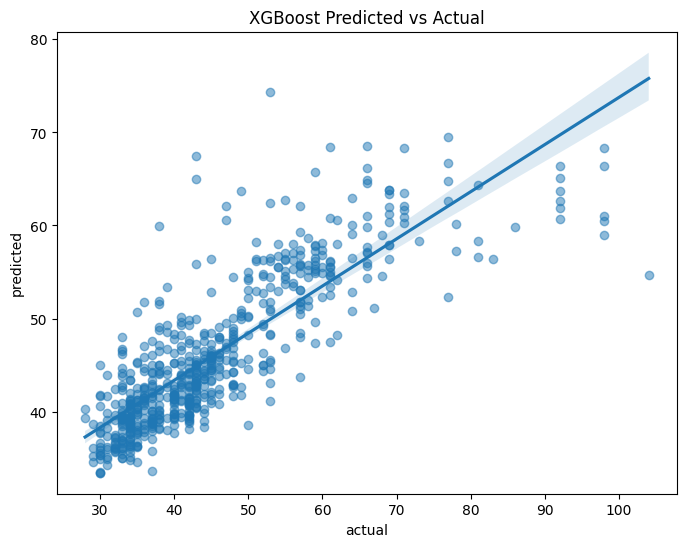

In [196]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout_b, y_holdout_b)

In [148]:
explainer = shap.Explainer(best_xgbr_model)

In [197]:
explainer = shap.Explainer(best_rfr_model)

In [151]:
shap_values = explainer(X_dupe)

In [ ]:
shap_values = explainer(X_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

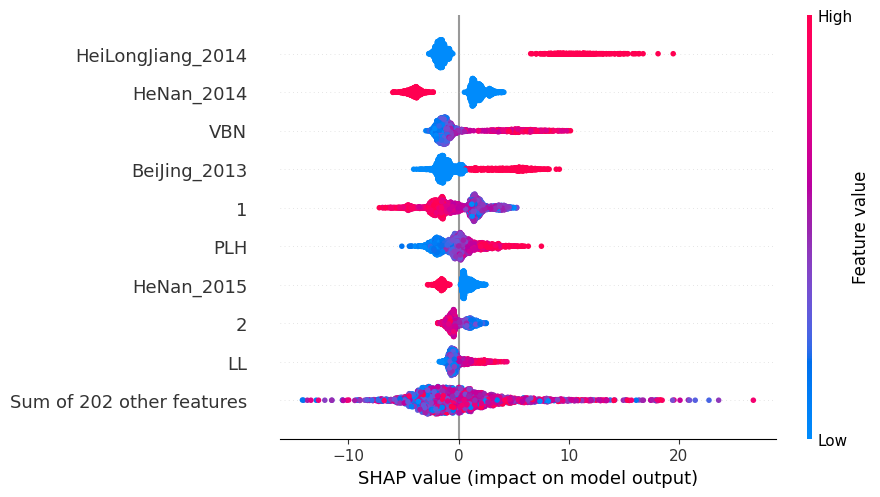

In [152]:
shap.plots.beeswarm(shap_values, show=False)

In [ ]:
shap.plots.beeswarm(shap_values, show=False)

<Figure size 2000x2000 with 0 Axes>

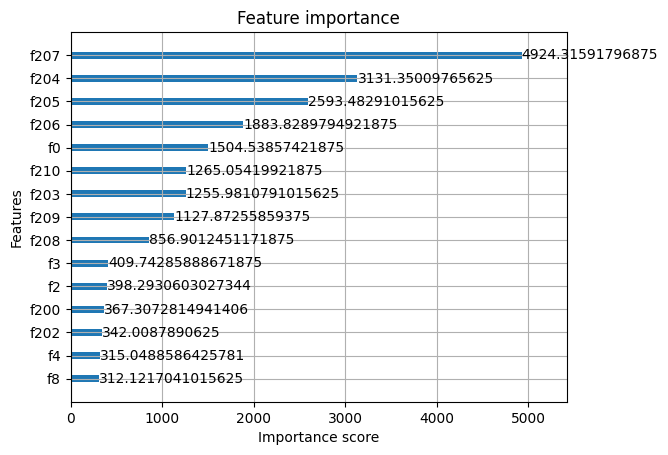

In [154]:
from xgboost import plot_importance
from matplotlib import pyplot
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

#### Only location models 

In [40]:
pca_loc.head()

,1,2,3,4,5,6,7,8,9,10,...,198,199,200,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,-0.003579,-0.081070,0.030498,1,0,0,0,0,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,-0.001273,0.016743,0.025923,0,0,1,0,0,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,0.001582,0.006455,-0.010067,0,0,1,0,0,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,0.022296,0.007699,-0.011343,0,1,0,0,0,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,-0.052144,0.060825,0.051451,0,1,0,0,0,1,0


In [41]:
pca_loc.shape

(2450, 207)

In [42]:
y.head()

,MD
Line,
s503,113.0
s2833,107.0
s1616,100.0
s833,103.0
s265,103.0


In [43]:
y.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s503 to s2236
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MD      2450 non-null   float64
dtypes: float64(1)
memory usage: 38.3+ KB


In [44]:
X_train, X_test, y_train, y_test = train_test_split(pca_loc, y, test_size=0.1, random_state=42)

In [33]:
X_train.head()

,1,2,3,4,5,6,7,8,9,10,...,198,199,200,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s863,0.020994,-0.017924,-0.000505,-0.028264,0.020462,-0.002946,-0.014835,0.009247,0.026842,-0.023992,...,0.032022,0.028184,0.002035,1,0,0,0,0,1,0
s338,-0.009844,0.013358,0.020992,-0.036998,-0.037106,0.035101,-0.000918,0.013954,-0.010888,0.013694,...,0.017068,-0.023994,0.061663,1,0,0,0,0,0,1
s582,-0.012012,0.057386,0.003213,-0.014743,0.008771,-0.007759,-0.014808,0.006685,-0.030697,-0.008176,...,-0.010025,0.009232,-0.013915,1,0,0,0,0,0,1
s216,0.034190,-0.020503,0.017794,-0.005123,0.023337,-0.005070,-0.013410,-0.050472,-0.024485,0.007292,...,-0.031187,0.008848,-0.022058,0,0,0,1,0,1,0
s473,0.003999,0.001473,0.015235,-0.027210,-0.046295,0.053714,-0.002097,0.001476,0.026196,-0.028050,...,0.009798,-0.022230,0.053671,0,1,0,0,0,0,1


In [34]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [38]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.8902412220036554), ('colsample_bytree', 1.0), ('gamma', 0.49999999999999994), ('learning_rate', 0.08064632372568156), ('max_delta_step', 13), ('max_depth', 6), ('min_child_weight', 2), ('n_estimators', 86), ('reg_alpha', 0.24868845907323975), ('reg_lambda', 1e-09), ('subsample', 1.0)])


In [ ]:
best_params = OrderedDict([('colsample_bylevel', 0.8902412220036554), ('colsample_bytree', 1.0), ('gamma', 0.49999999999999994), ('learning_rate', 0.08064632372568156), ('max_delta_step', 13), ('max_depth', 6), ('min_child_weight', 2), ('n_estimators', 86), ('reg_alpha', 0.24868845907323975), ('reg_lambda', 1e-09), ('subsample', 1.0)])
#best_xgbreg = xgb.XGBRegressor(**best_params)

In [39]:
pca_loc = pca_loc.to_numpy()
y = y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, pca_loc, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.550491935747669
RMSE for dataset is:10.284525105833994& mean of this fold is 116.59591836734694
this is 8.820656202931207% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6396694829513029
RMSE for dataset is:9.540374042208203& mean of this fold is 116.91836734693878
this is 8.15985910400073% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5732310052273948
RMSE for dataset is:9.742198231828707& mean of this fold is 115.82040816326531
this is 8.411469434726646% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7257535848843562
RMSE for dataset is:8.401967467908896& mean of this fold is 115.88979591836734
this is 7.249963123437748% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6221945586043376
RMSE for datase

In [52]:
#pickle.dump(best_xgbr_model, open("pca_200_best_model_onlyloc_xgbr_md.pickle.dat", "wb"))
best_xgbr_model = pickle.load(open("../pickle_bestmodels/pca_200_best_model_onlyloc_xgbr_md.pickle.dat", "rb"))

In [55]:
X_holdout_m = pca_full_holdout_m.iloc[:, :511]
X_holdout_m.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,0.005044,-0.006670,...,4.96600,94.8000,1.40000,0,0,0,0,1,1,0
s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,-0.028440,0.038526,...,6.11333,120.8000,2.80000,0,0,1,0,0,0,1
s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,0.023780,0.003327,...,4.19333,60.4000,1.60000,0,1,0,0,0,1,0
s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,-0.017821,-0.049911,...,7.30667,63.0000,1.80000,0,1,0,0,0,0,1
s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,0.045854,-0.018372,...,6.93333,97.1667,4.33333,1,0,0,0,0,0,1


In [56]:
y_holdout_m = pca_full_holdout_m.iloc[:, 511:]
y_holdout_m.head()

,MD
Line,
s2692,117.0
s131,115.0
s272,100.0
s344,107.0
s324,168.0


In [57]:
# Ensure both training and holdout datasets have the same columns
pca_loc_dupe, X_holdout_m = pca_loc_dupe.align(X_holdout_m, join='inner', axis=1)

In [58]:
X_holdout_m.head()

,1,2,3,4,5,6,7,8,9,10,...,198,199,200,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,0.005044,-0.006670,...,0.010179,0.000727,-0.004895,0,0,0,0,1,1,0
s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,-0.028440,0.038526,...,0.032078,0.011147,-0.025686,0,0,1,0,0,0,1
s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,0.023780,0.003327,...,-0.013848,0.003910,-0.003303,0,1,0,0,0,1,0
s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,-0.017821,-0.049911,...,-0.007527,0.009277,0.008827,0,1,0,0,0,0,1
s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,0.045854,-0.018372,...,-0.018169,-0.033234,0.040716,1,0,0,0,0,0,1


In [59]:
X_holdout_m = X_holdout_m.to_numpy()
y_holdout_m = y_holdout_m.to_numpy()

R^2 Value of Holdout: 0.72
RMSE of Holdout: 9.79
Mean of Holdout: 115.12
This is 8.50% of the mean pheno data
0 117.0 116.85515
1 115.0 115.228745
2 100.0 100.08524
3 107.0 106.5743
4 168.0 146.38622


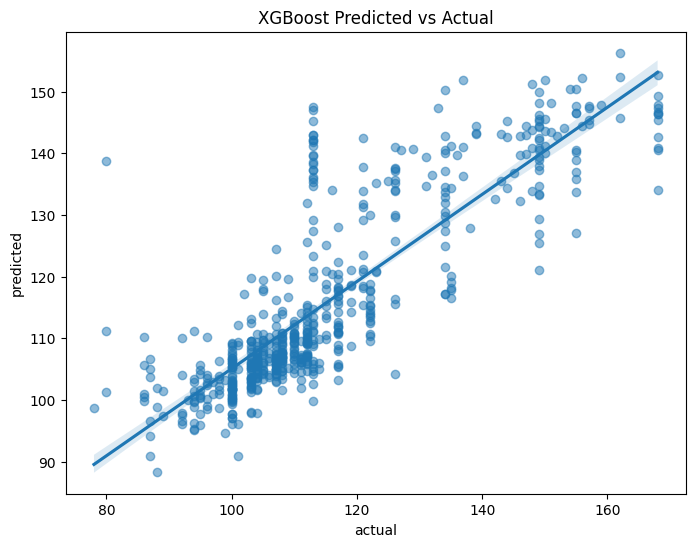

In [60]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout_m, y_holdout_m)

In [47]:
explainer = shap.Explainer(best_xgbr_model)

In [48]:
shap_values = explainer(pca_loc_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

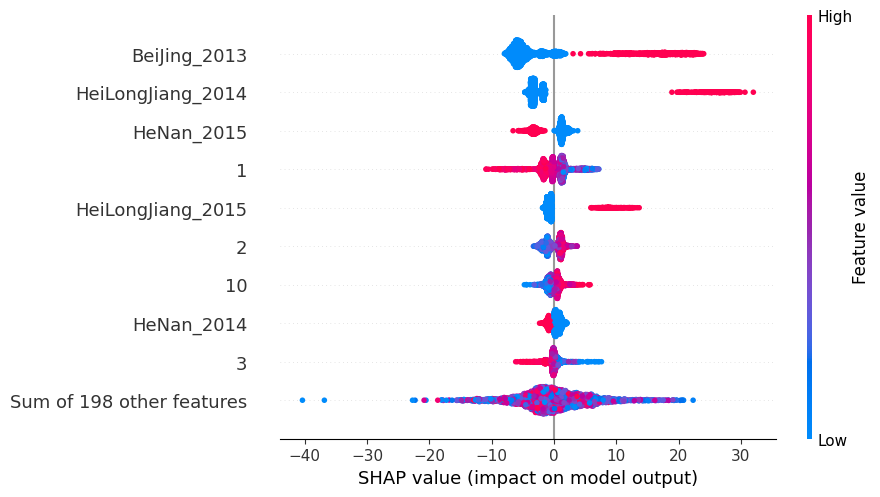

In [49]:
shap.plots.beeswarm(shap_values, show=False)

<Figure size 2000x2000 with 0 Axes>

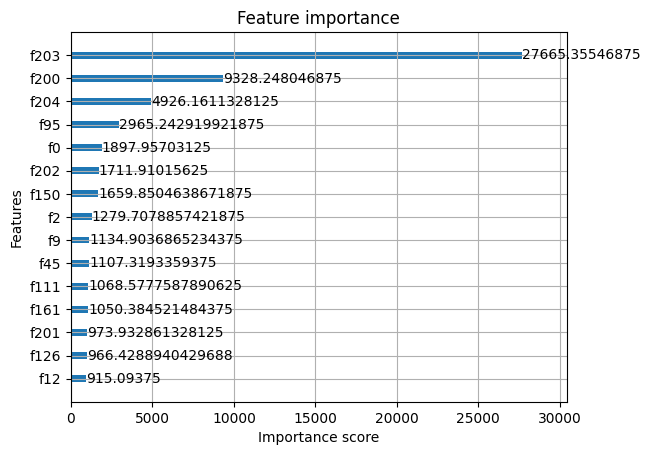

In [50]:
from xgboost import plot_importance
from matplotlib import pyplot
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

In [51]:
#### RF models

In [52]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 32), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 500)])


In [42]:
from sklearn.svm import SVR
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2), ('kernel', 'poly')])


In [ ]:
best_rfr_model =  OrderedDict([('bootstrap', True), ('max_depth', 32), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 500)])

In [53]:
best_rfr_model = eval_k_fold(best_rfreg, pca_loc, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.32640360052849604
RMSE for dataset is:11.913962112053166& mean of this fold is 114.90612244897959
this is 10.368431079330158% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.5796459883860625
RMSE for dataset is:12.547874640036786& mean of this fold is 117.17959183673469
this is 10.70824231707483% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.6548105953062611
RMSE for dataset is:13.170535804092454& mean of this fold is 117.71020408163265
this is 11.188949935859952% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.7021581347476493
RMSE for dataset is:13.559734576685484& mean of this fold is 117.05102040816327
this is 11.58446507292457% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.3621881666369833
RM

In [43]:
pca_loc = pca_loc.to_numpy()
y = y.to_numpy() 
best_svr_model = eval_k_fold(best_svreg, pca_loc, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.2876442045258901
RMSE for dataset is:11.582258614487786& mean of this fold is 118.17551020408163
this is 9.800895798533857% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.19495501968204554
RMSE for dataset is:11.832192370189633& mean of this fold is 116.61224489795919
this is 10.146612288052012% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.10117103388569126
RMSE for dataset is:12.325031252140393& mean of this fold is 116.2530612244898
this is 10.601898240202221% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.14633805032488978
RMSE for dataset is:12.740547136886176& mean of this fold is 115.79183673469387
this is 11.002975249522766% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.17714105887759224
RMSE

In [64]:
#pickle.dump(best_rfr_model, open("pca_200_best_model_onlyloc_rfr_md.pickle.dat", "wb"))
best_rfr_model = pickle.load(open("../pickle_bestmodels/pca_200_best_model_onlyloc_rfr_md.pickle.dat", "rb"))

In [65]:
#pickle.dump(best_svr_model, open("pca_200_best_model_onlyloc_svr_md.pickle.dat", "wb"))
best_svr_model = pickle.load(open("../pickle_bestmodels/pca_200_best_model_onlyloc_svr_md.pickle.dat", "rb"))

R^2 Value of Holdout: 0.58
RMSE of Holdout: 11.95
Mean of Holdout: 115.12
This is 10.38% of the mean pheno data
0 117.0 125.3411367781155
1 115.0 122.238
2 100.0 104.119
3 107.0 109.1787619047619
4 168.0 132.908


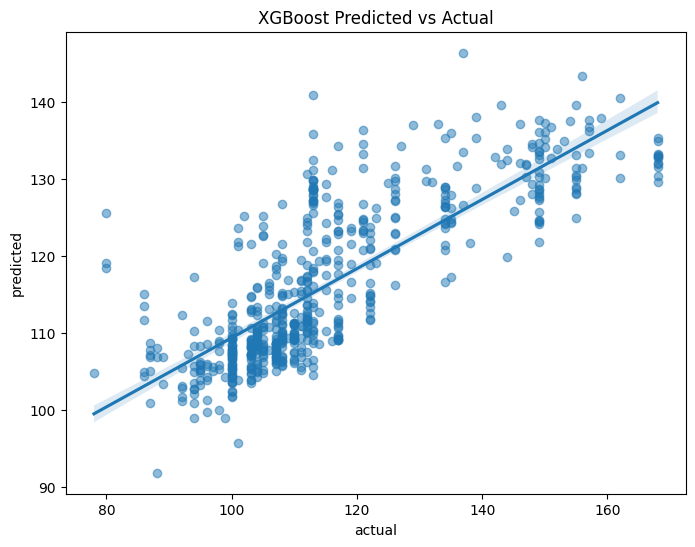

In [66]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout_m, y_holdout_m)

R^2 Value of Holdout: 0.60
RMSE of Holdout: 11.65
Mean of Holdout: 115.12
This is 10.12% of the mean pheno data
0 117.0 118.90474028157618
1 115.0 106.27554508081755
2 100.0 107.01314452934713
3 107.0 106.71406086268144
4 168.0 135.7535268027681


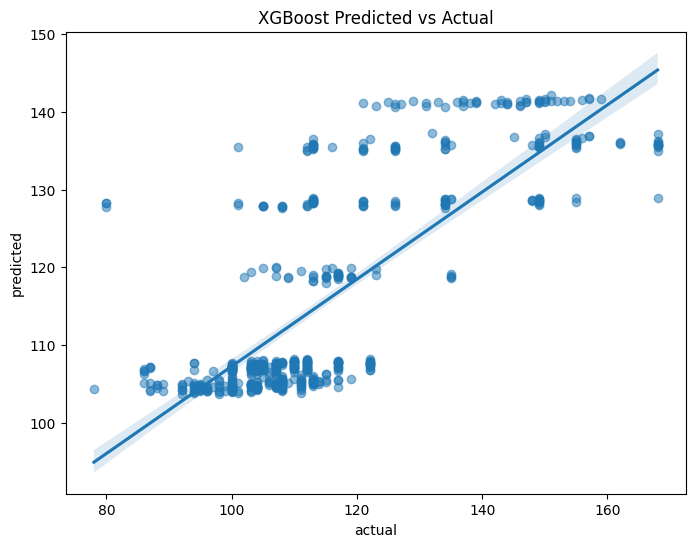

In [67]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout_m, y_holdout_m)

### Only PCs

In [68]:
only_pca.head()

,1,2,3,4,5,6,7,8,9,10,...,193,194,195,196,197,198,199,200,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,0.000610,0.020551,0.029000,-0.032989,0.020069,-0.003579,-0.081070,0.030498,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,-0.004685,-0.021917,0.005822,0.029612,0.060264,-0.001273,0.016743,0.025923,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,-0.000054,0.011717,-0.001412,0.008280,-0.023776,0.001582,0.006455,-0.010067,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,0.039625,-0.011997,-0.002396,0.006086,0.001528,0.022296,0.007699,-0.011343,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,-0.054112,-0.037200,-0.008555,-0.018565,0.053066,-0.052144,0.060825,0.051451,1,0


In [69]:
only_pca.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s503 to s2236
Columns: 202 entries, 1 to landrace
dtypes: float64(200), int64(2)
memory usage: 3.8+ MB


In [70]:
only_pca_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,193,194,195,196,197,198,199,200,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,0.000610,0.020551,0.029000,-0.032989,0.020069,-0.003579,-0.081070,0.030498,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,-0.004685,-0.021917,0.005822,0.029612,0.060264,-0.001273,0.016743,0.025923,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,-0.000054,0.011717,-0.001412,0.008280,-0.023776,0.001582,0.006455,-0.010067,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,0.039625,-0.011997,-0.002396,0.006086,0.001528,0.022296,0.007699,-0.011343,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,-0.054112,-0.037200,-0.008555,-0.018565,0.053066,-0.052144,0.060825,0.051451,1,0


In [71]:
y = pca_full_train_m.iloc[:, 511:]
y.head()

,MD
Line,
s503,113.0
s2833,107.0
s1616,100.0
s833,103.0
s265,103.0


In [72]:
y.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s503 to s2236
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MD      2450 non-null   float64
dtypes: float64(1)
memory usage: 38.3+ KB


In [73]:
X_train, X_test, y_train, y_test = train_test_split(only_pca, y, test_size=0.1, random_state=42)

In [52]:
X_train.head()

,1,2,3,4,5,6,7,8,9,10,...,193,194,195,196,197,198,199,200,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s863,0.020994,-0.017924,-0.000505,-0.028264,0.020462,-0.002946,-0.014835,0.009247,0.026842,-0.023992,...,-0.007479,0.000605,0.015212,-0.011716,0.006259,0.032022,0.028184,0.002035,1,0
s338,-0.009844,0.013358,0.020992,-0.036998,-0.037106,0.035101,-0.000918,0.013954,-0.010888,0.013694,...,0.065126,-0.012790,0.043200,0.048562,-0.071636,0.017068,-0.023994,0.061663,0,1
s582,-0.012012,0.057386,0.003213,-0.014743,0.008771,-0.007759,-0.014808,0.006685,-0.030697,-0.008176,...,0.000377,0.003428,-0.001587,-0.029051,0.020238,-0.010025,0.009232,-0.013915,0,1
s216,0.034190,-0.020503,0.017794,-0.005123,0.023337,-0.005070,-0.013410,-0.050472,-0.024485,0.007292,...,0.007391,-0.001855,-0.000952,-0.026029,-0.001117,-0.031187,0.008848,-0.022058,1,0
s473,0.003999,0.001473,0.015235,-0.027210,-0.046295,0.053714,-0.002097,0.001476,0.026196,-0.028050,...,0.015574,0.017033,0.026996,0.006843,0.023382,0.009798,-0.022230,0.053671,0,1


In [53]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [64]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.714410246036246), ('colsample_bytree', 0.16651128214177977), ('gamma', 2.78385264245566e-06), ('learning_rate', 0.030906243792298886), ('max_delta_step', 5), ('max_depth', 3), ('min_child_weight', 4), ('n_estimators', 131), ('reg_alpha', 3.0615288992985453e-07), ('reg_lambda', 6.859084823019396e-08), ('subsample', 0.4952131428234053)])


In [ ]:
OrderedDict([('colsample_bylevel', 0.714410246036246), ('colsample_bytree', 0.16651128214177977), ('gamma', 2.78385264245566e-06), ('learning_rate', 0.030906243792298886), ('max_delta_step', 5), ('max_depth', 3), ('min_child_weight', 4), ('n_estimators', 131), ('reg_alpha', 3.0615288992985453e-07), ('reg_lambda', 6.859084823019396e-08), ('subsample', 0.4952131428234053)])

In [65]:
only_pca = only_pca.to_numpy()
y = y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, only_pca, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -53.58657308253846
RMSE for dataset is:20.175904004064122& mean of this fold is 117.13061224489796
this is 17.225133222970033% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -42.894909653679434
RMSE for dataset is:18.50795455914768& mean of this fold is 115.84489795918367
this is 15.97649519762942% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -44.219906764645664
RMSE for dataset is:18.583205452558737& mean of this fold is 116.5061224489796
this is 15.950411070196505% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -52.665148167983055
RMSE for dataset is:19.755152526623306& mean of this fold is 117.91020408163266
this is 16.754404489832144% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -38.056251291536114
RMSE 

In [74]:
#pickle.dump(best_xgbr_model, open("pca_200_best_model_onlypcs_xgbr_md.pickle.dat", "wb"))
best_xgbr_model = pickle.load(open("../pickle_bestmodels/pca_200_best_model_onlypcs_xgbr_md.pickle.dat", "rb"))

In [75]:
pca_full_holdout_m.head()

,1,2,3,4,5,6,7,8,9,10,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,0.005044,-0.006670,...,94.8000,1.40000,0,0,0,0,1,1,0,117.0
s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,-0.028440,0.038526,...,120.8000,2.80000,0,0,1,0,0,0,1,115.0
s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,0.023780,0.003327,...,60.4000,1.60000,0,1,0,0,0,1,0,100.0
s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,-0.017821,-0.049911,...,63.0000,1.80000,0,1,0,0,0,0,1,107.0
s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,0.045854,-0.018372,...,97.1667,4.33333,1,0,0,0,0,0,1,168.0


In [76]:
X_holdout_m = pca_full_holdout_m.iloc[:, :511]
X_holdout_m.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,0.005044,-0.006670,...,4.96600,94.8000,1.40000,0,0,0,0,1,1,0
s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,-0.028440,0.038526,...,6.11333,120.8000,2.80000,0,0,1,0,0,0,1
s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,0.023780,0.003327,...,4.19333,60.4000,1.60000,0,1,0,0,0,1,0
s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,-0.017821,-0.049911,...,7.30667,63.0000,1.80000,0,1,0,0,0,0,1
s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,0.045854,-0.018372,...,6.93333,97.1667,4.33333,1,0,0,0,0,0,1


In [77]:
y_holdout_m = pca_full_holdout_m.iloc[:, 511:]
y_holdout_m.head()

,MD
Line,
s2692,117.0
s131,115.0
s272,100.0
s344,107.0
s324,168.0


In [78]:
# Ensure both training and holdout datasets have the same columns
only_pca_dupe, X_holdout_m = only_pca_dupe.align(X_holdout_m, join='inner', axis=1)

In [79]:
X_holdout_m.head()

,1,2,3,4,5,6,7,8,9,10,...,193,194,195,196,197,198,199,200,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,0.005044,-0.006670,...,-0.004072,-0.010697,-0.007011,0.002740,0.006326,0.010179,0.000727,-0.004895,1,0
s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,-0.028440,0.038526,...,-0.018952,0.001183,0.029790,0.031279,0.024640,0.032078,0.011147,-0.025686,0,1
s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,0.023780,0.003327,...,-0.016340,-0.007137,-0.007714,0.001504,-0.004550,-0.013848,0.003910,-0.003303,1,0
s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,-0.017821,-0.049911,...,0.009288,0.005665,-0.002954,0.010800,0.001373,-0.007527,0.009277,0.008827,0,1
s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,0.045854,-0.018372,...,-0.070668,-0.027317,-0.026771,-0.057435,-0.019804,-0.018169,-0.033234,0.040716,0,1


In [80]:
X_holdout_m = X_holdout_m.to_numpy()
y_holdout_m = y_holdout_m.to_numpy()

R^2 Value of Holdout: 0.01
RMSE of Holdout: 18.33
Mean of Holdout: 115.12
This is 15.92% of the mean pheno data
0 117.0 116.26546
1 115.0 126.07866
2 100.0 115.27641
3 107.0 115.537544
4 168.0 117.39183


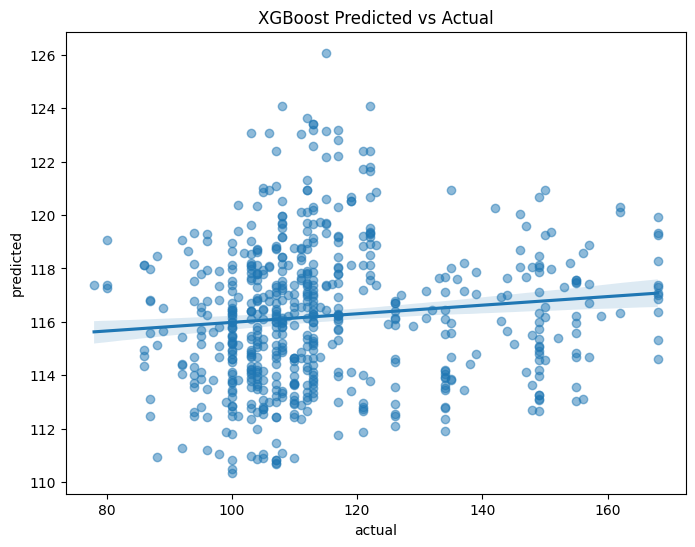

In [81]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout_m, y_holdout_m)

In [ ]:
#### RF Models

In [75]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 3), ('max_features', 'sqrt'), ('max_samples', 0.7096966066664374), ('min_samples_leaf', 10), ('min_samples_split', 20), ('n_estimators', 91)])


In [60]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 0.5), ('kernel', 'rbf')])


In [ ]:
OrderedDict([('bootstrap', True), ('max_depth', 3), ('max_features', 'sqrt'), ('max_samples', 0.7096966066664374), ('min_samples_leaf', 10), ('min_samples_split', 20), ('n_estimators', 91)])

In [76]:
best_rfr_model = eval_k_fold(best_rfreg, only_pca, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -310.70578205834585
RMSE for dataset is:18.34168801095641& mean of this fold is 113.62448979591836
this is 16.14237216281457% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -162.16574141023816
RMSE for dataset is:18.392914085307194& mean of this fold is 117.6
this is 15.64023306573741% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -147.97363169111262
RMSE for dataset is:17.117956300442316& mean of this fold is 114.61224489795919
this is 14.935538794901593% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -192.207966679763
RMSE for dataset is:19.80233859863836& mean of this fold is 117.99183673469388
this is 16.782803918176278% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -244.89424932347922
RMSE for dataset is:

In [61]:
only_pca = only_pca.to_numpy()
y = y.to_numpy()
best_svr_model = eval_k_fold(best_svreg, only_pca, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -149.1716671558922
RMSE for dataset is:18.802047630892737& mean of this fold is 116.05102040816327
this is 16.201535811373326% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -238.95563424172872
RMSE for dataset is:20.637428944641933& mean of this fold is 117.59591836734694
this is 17.54944323847584% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -191.99328126852637
RMSE for dataset is:20.33748454462841& mean of this fold is 117.11836734693877
this is 17.36489758637332% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -185.38557438408196
RMSE for dataset is:19.480750611624515& mean of this fold is 115.84897959183674
this is 16.8156428138252% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -234.12590051571914
RMSE fo

In [82]:
#pickle.dump(best_rfr_model, open("pca_200_best_model_onlypcs_rfr_md.pickle.dat", "wb"))
best_rfr_model = pickle.load(open("../pickle_bestmodels/pca_200_best_model_onlypcs_rfr_md.pickle.dat", "rb"))

In [83]:
#pickle.dump(best_svr_model, open("pca_200_best_model_onlypcs_svr_md.pickle.dat", "wb"))
best_svr_model = pickle.load(open("../pickle_bestmodels/pca_200_best_model_onlypcs_svr_md.pickle.dat", "rb"))

R^2 Value of Holdout: -0.00
RMSE of Holdout: 18.44
Mean of Holdout: 115.12
This is 16.02% of the mean pheno data
0 117.0 114.99603268641889
1 115.0 121.40677674681943
2 100.0 115.07112378837705
3 107.0 114.78270901876976
4 168.0 116.98543047918942


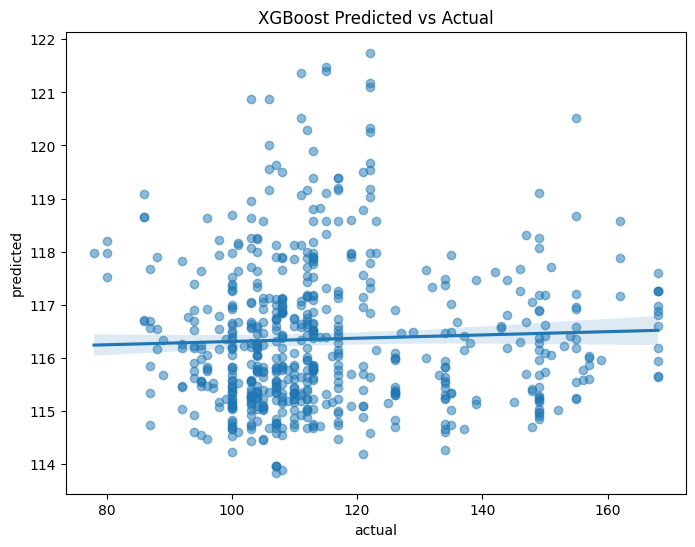

In [84]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout_m, y_holdout_m)

R^2 Value of Holdout: -0.04
RMSE of Holdout: 18.80
Mean of Holdout: 115.12
This is 16.33% of the mean pheno data
0 117.0 109.47304954914124
1 115.0 113.06497304080115
2 100.0 110.08046366213945
3 107.0 110.55759631116683
4 168.0 111.35969865221928


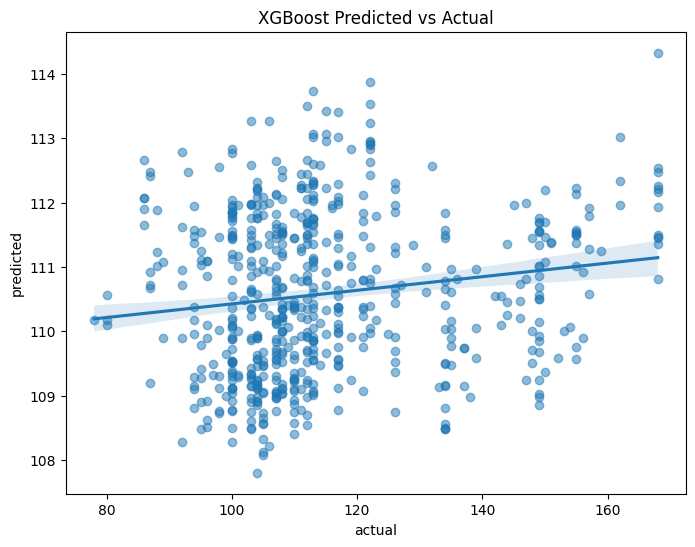

In [85]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout_m, y_holdout_m)

# PC500 models

In [86]:
y = pca_full_train_m.iloc[:, 511:]
y.head()

,MD
Line,
s503,113.0
s2833,107.0
s1616,100.0
s833,103.0
s265,103.0


In [87]:
X = pca_full_train_m.iloc[:, 0:511]
X.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,6.60000,43.9333,5.33333,1,0,0,0,0,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,5.54667,83.2000,1.40000,0,0,1,0,0,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,8.32000,60.8000,3.80000,0,0,1,0,0,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,3.78000,67.0000,0.80000,0,1,0,0,0,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,7.43333,79.0000,1.00000,0,1,0,0,0,1,0


In [88]:
X_dupe = pca_full_train_m.iloc[:, 0:511]
X_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,6.60000,43.9333,5.33333,1,0,0,0,0,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,5.54667,83.2000,1.40000,0,0,1,0,0,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,8.32000,60.8000,3.80000,0,0,1,0,0,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,3.78000,67.0000,0.80000,0,1,0,0,0,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,7.43333,79.0000,1.00000,0,1,0,0,0,1,0


In [89]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [68]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [96]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

Fitting 5 folds for each of 12 candidates, totalling 60 fits


KeyboardInterrupt: 

Process LokyProcess-453:
Process LokyProcess-454:
Process LokyProcess-450:
Traceback (most recent call last):
  File "/home/supadhyaya/.local/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py", line 463, in _process_worker
    r = call_item()
  File "/home/supadhyaya/.local/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py", line 291, in __call__
    return self.fn(*self.args, **self.kwargs)
  File "/home/supadhyaya/.local/lib/python3.10/site-packages/joblib/parallel.py", line 598, in __call__
    return [func(*args, **kwargs)
  File "/home/supadhyaya/.local/lib/python3.10/site-packages/joblib/parallel.py", line 598, in <listcomp>
    return [func(*args, **kwargs)
  File "/home/supadhyaya/.local/lib/python3.10/site-packages/sklearn/utils/parallel.py", line 139, in __call__
    return self.function(*args, **kwargs)
  File "/home/supadhyaya/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
  

In [97]:

best_params = {
    'colsample_bylevel': 0.16975074821232053,
    'colsample_bytree': 0.7700635638092945,
    'gamma': 0.49999999999999994,
    'learning_rate': 0.08281369575374707,
    'max_delta_step': 20,
    'max_depth': 4,
    'min_child_weight': 2,
    'n_estimators': 200,
    'reg_alpha': 1.3998058433748922e-09,
    'reg_lambda': 6.998838349296903,
    'subsample': 0.9094311201012985
}
best_xgbreg = xgb.XGBRegressor(**best_params)

In [99]:
X = X.to_numpy()
y = y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, X, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6503452432531805
RMSE for dataset is:6.5354842228958026& mean of this fold is 46.29133858267716
this is 14.118157787170727% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5336221752026762
RMSE for dataset is:7.669785639630892& mean of this fold is 48.188976377952756
this is 15.916058435181753% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7020061370165448
RMSE for dataset is:5.9186098030943946& mean of this fold is 46.696850393700785
this is 12.674537475642664% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6977807666756852
RMSE for dataset is:6.2051900777780284& mean of this fold is 46.767716535433074
this is 13.268105730748541% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5980217130078358
RMSE for

In [100]:
pickle.dump(best_xgbr_model, open("pca_500_best_model_allfeats_xgbr_bbd.pickle.dat", "wb"))
#best_rfr_model = pickle.load(open("pca_500_best_model_allfeats_xgbr_bbd.pickle.dat", "rb"))

In [101]:
X_holdout_b = pca_full_holdout_b.iloc[:, 0:511]
X_holdout_b.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,0.017870,0.009386,...,7.44000,90.0,1.00000,0,1,0,0,0,0,1
s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,0.004342,-0.014619,...,6.52000,200.4,1.40000,0,0,1,0,0,0,1
s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,0.019218,0.000583,...,6.72667,46.6,0.80000,0,1,0,0,0,1,0
s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,-0.014827,0.038961,...,5.53333,49.8,4.66667,0,0,0,1,0,1,0
s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,-0.046108,0.035115,...,6.07333,61.6,1.80000,0,1,0,0,0,1,0


In [102]:
y_holdout_b = pca_full_holdout_b.iloc[:, 511:]
y_holdout_b.head()

,BBD
Line,
s143,42
s525,42
s2272,32
s2255,56
s1588,32


In [103]:
# Ensure both training and holdout datasets have the same columns
X_dupe, X_holdout_b = X_dupe.align(X_holdout_b, join='inner', axis=1)

In [104]:
X_holdout_b = X_holdout_b.to_numpy()
y_holdout_b = y_holdout_b.to_numpy()

R^2 Value of Holdout: 0.60
RMSE of Holdout: 6.85
Mean of Holdout: 45.55
This is 15.03% of the mean pheno data
0 42 49.401085
1 42 42.54959
2 32 32.409245
3 56 59.708187
4 32 37.017273
5 48 45.512524


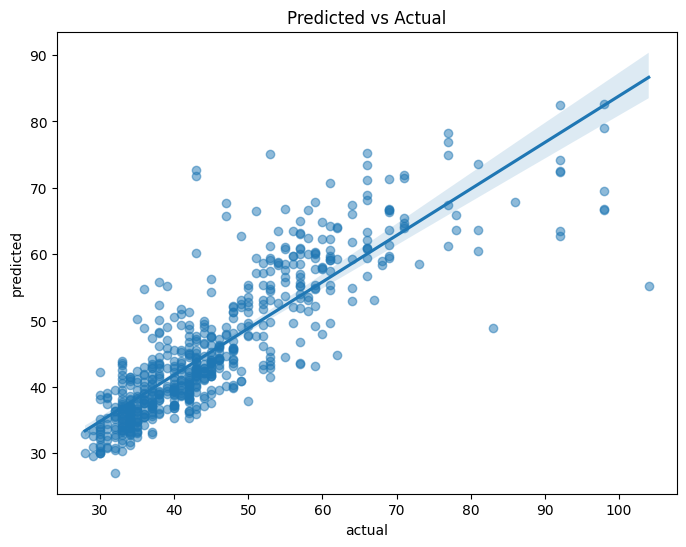

In [105]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout_b, y_holdout_b)

In [180]:
explainer = shap.Explainer(best_xgbr_model)

In [181]:
shap_values = explainer(X_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

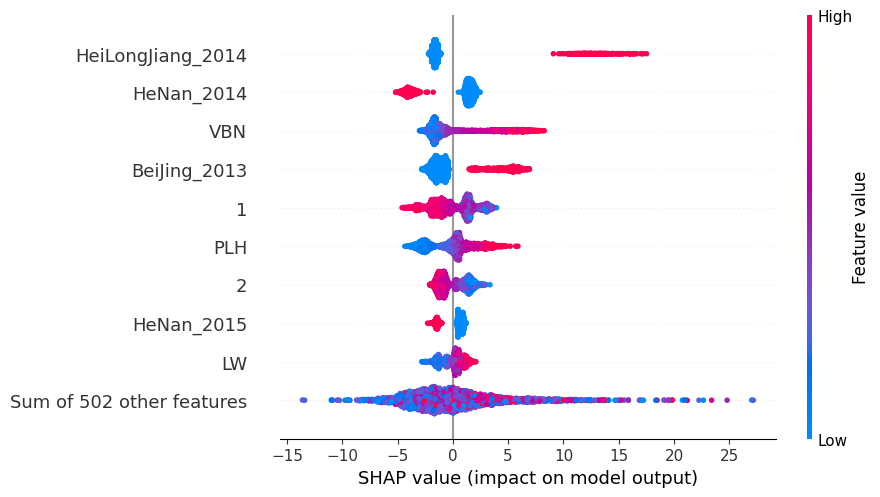

In [182]:
shap.plots.beeswarm(shap_values, show=False)

<Figure size 2000x2000 with 0 Axes>

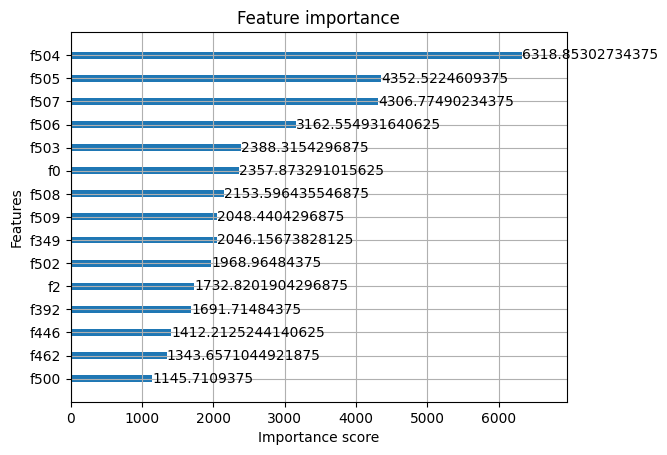

In [183]:
from xgboost import plot_importance
from matplotlib import pyplot
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

In [22]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 50), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 500)])


In [ ]:
#best_rfreg = OrderedDict([('bootstrap', True), 
                          ('max_depth', 50), 
                          ('max_features', 'sqrt'), 
                          ('max_samples', 1.0), 
                          ('min_samples_leaf', 1), 
                          ('min_samples_split', 2), 
                          ('n_estimators', 500)])

In [24]:
X = X.to_numpy()
y = y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, X, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.8569090683714495
RMSE for dataset is:9.04341484305691& mean of this fold is 46.44094488188976
this is 19.47293464001742% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.18275105267094838
RMSE for dataset is:8.10799639242412& mean of this fold is 46.6496062992126
this is 17.38063198308487% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.7956073890945945
RMSE for dataset is:9.094566921444166& mean of this fold is 47.59842519685039
this is 19.106865161677568% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.627531607898532
RMSE for dataset is:8.457826788225955& mean of this fold is 45.488188976377955
this is 18.59345684792619% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.5985667568916357
RMSE for datas

In [25]:
pickle.dump(best_rfr_model, open("pca_500_best_model_allfeats_rfr_bbd.pickle.dat", "wb"))
#best_rfr_model = pickle.load(open("pca_500_best_model_allfeats_rfr_bbd.pickle.dat", "rb"))

R^2 Value of Holdout: -0.61
RMSE of Holdout: 8.99
Mean of Holdout: 45.55
This is 19.73% of the mean pheno data
0 42 51.938
1 42 45.51
2 32 36.504
3 56 55.756
4 32 42.301333333333325
5 48 44.64


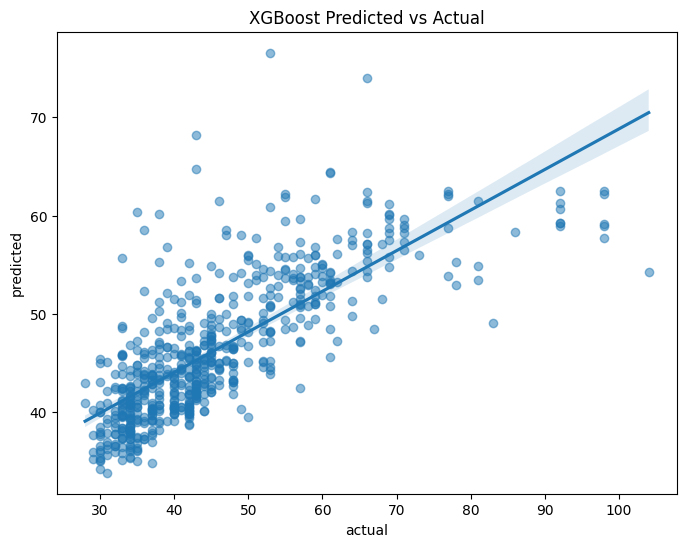

In [30]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout_b, y_holdout_b)

In [32]:
explainer = shap.Explainer(best_rfr_model)

In [ ]:
shap_values = explainer(X_dupe)

In [ ]:
shap.plots.beeswarm(shap_values, show=False)

### Only location Models

In [90]:
pca_loc= X.drop(['VBN', 'LL', 'LW', 'PLH'], axis=1)
pca_loc.head()

,1,2,3,4,5,6,7,8,9,10,...,498,499,500,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,-0.021508,-0.024271,-0.011418,1,0,0,0,0,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,0.005446,0.019524,0.054528,0,0,1,0,0,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,0.007665,-0.009861,-0.004266,0,0,1,0,0,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,0.029024,0.018871,-0.007392,0,1,0,0,0,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,0.025662,0.057667,0.006056,0,1,0,0,0,1,0


In [91]:
pca_loc_dupe = X.drop(['VBN', 'LL', 'LW', 'PLH'], axis=1)
pca_loc_dupe .head()

,1,2,3,4,5,6,7,8,9,10,...,498,499,500,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,-0.021508,-0.024271,-0.011418,1,0,0,0,0,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,0.005446,0.019524,0.054528,0,0,1,0,0,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,0.007665,-0.009861,-0.004266,0,0,1,0,0,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,0.029024,0.018871,-0.007392,0,1,0,0,0,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,0.025662,0.057667,0.006056,0,1,0,0,0,1,0


In [92]:
y = pca_full_train_m.iloc[:, 511:]
y.head()

,MD
Line,
s503,113.0
s2833,107.0
s1616,100.0
s833,103.0
s265,103.0


In [72]:
X_train, X_test, y_train, y_test = train_test_split(pca_loc, y, test_size=0.1, random_state=42)

In [73]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [87]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.32513276360584337), ('colsample_bytree', 0.7441631972964099), ('gamma', 1.0018239220770246e-05), ('learning_rate', 0.03685249314342051), ('max_delta_step', 15), ('max_depth', 31), ('min_child_weight', 10), ('n_estimators', 200), ('reg_alpha', 0.05639729435110135), ('reg_lambda', 1.4938425796098453), ('subsample', 0.8414111163579864)])


In [28]:
best_params = {
    'colsample_bylevel': 0.32513276360584337,
    'colsample_bytree': 0.7441631972964099,
    'gamma': 1.0018239220770246e-05,
    'learning_rate': 0.03685249314342051,
    'max_delta_step': 15,
    'max_depth': 31,
    'min_child_weight': 10,
    'n_estimators': 200,
    'reg_alpha': 0.05639729435110135,
    'reg_lambda': 1.4938425796098453,
    'subsample': 0.8414111163579864
}
best_xgbreg = xgb.XGBRegressor(**best_params)

In [ ]:
OrderedDict([('colsample_bylevel', 0.32513276360584337), ('colsample_bytree', 0.7441631972964099), ('gamma', 1.0018239220770246e-05), ('learning_rate', 0.03685249314342051), ('max_delta_step', 15), ('max_depth', 31), ('min_child_weight', 10), ('n_estimators', 200), ('reg_alpha', 0.05639729435110135), ('reg_lambda', 1.4938425796098453), ('subsample', 0.8414111163579864)])

In [29]:
pca_loc = pca_loc.to_numpy()
y = y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, pca_loc, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.4631325832125983
RMSE for dataset is:9.71157564803792& mean of this fold is 115.92244897959183
this is 8.37764879324422% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.4903473958262474
RMSE for dataset is:10.224411831980607& mean of this fold is 117.22857142857143
this is 8.721774655601298% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6268614470836714
RMSE for dataset is:8.644063316543932& mean of this fold is 116.08571428571429
this is 7.446276546370603% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6334714203448373
RMSE for dataset is:8.936480559124288& mean of this fold is 115.78367346938775
this is 7.718256202578526% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5297815962382182
RMSE for datase

In [93]:
#pickle.dump(best_xgbr_model, open("pca_500_best_model_onlyloc_xgbr_md.pickle.dat", "wb"))
best_xgbr_model = pickle.load(open("../pickle_bestmodels/pca_500_best_model_onlyloc_xgbr_md.pickle.dat", "rb"))

In [94]:
pca_full_holdout_m.head()

,1,2,3,4,5,6,7,8,9,10,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,0.005044,-0.006670,...,94.8000,1.40000,0,0,0,0,1,1,0,117.0
s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,-0.028440,0.038526,...,120.8000,2.80000,0,0,1,0,0,0,1,115.0
s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,0.023780,0.003327,...,60.4000,1.60000,0,1,0,0,0,1,0,100.0
s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,-0.017821,-0.049911,...,63.0000,1.80000,0,1,0,0,0,0,1,107.0
s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,0.045854,-0.018372,...,97.1667,4.33333,1,0,0,0,0,0,1,168.0


In [95]:
X_holdout_m = pca_full_holdout_m.iloc[:, :511]
X_holdout_m.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,0.005044,-0.006670,...,4.96600,94.8000,1.40000,0,0,0,0,1,1,0
s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,-0.028440,0.038526,...,6.11333,120.8000,2.80000,0,0,1,0,0,0,1
s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,0.023780,0.003327,...,4.19333,60.4000,1.60000,0,1,0,0,0,1,0
s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,-0.017821,-0.049911,...,7.30667,63.0000,1.80000,0,1,0,0,0,0,1
s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,0.045854,-0.018372,...,6.93333,97.1667,4.33333,1,0,0,0,0,0,1


In [96]:
y_holdout_m = pca_full_holdout_m.iloc[:, 511:]
y_holdout_m.head()

,MD
Line,
s2692,117.0
s131,115.0
s272,100.0
s344,107.0
s324,168.0


In [97]:
# Ensure both training and holdout datasets have the same columns
pca_loc_dupe, X_holdout_m = pca_loc_dupe.align(X_holdout_m, join='inner', axis=1)

In [98]:
X_holdout_m.head()

,1,2,3,4,5,6,7,8,9,10,...,498,499,500,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,0.005044,-0.006670,...,-0.004834,0.016250,-0.003984,0,0,0,0,1,1,0
s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,-0.028440,0.038526,...,-0.005636,-0.008737,0.009723,0,0,1,0,0,0,1
s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,0.023780,0.003327,...,0.000757,-0.003276,0.000108,0,1,0,0,0,1,0
s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,-0.017821,-0.049911,...,-0.013631,-0.001659,0.012328,0,1,0,0,0,0,1
s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,0.045854,-0.018372,...,0.030966,-0.004702,-0.020557,1,0,0,0,0,0,1


In [99]:
X_holdout_m = X_holdout_m.to_numpy()
y_holdout_m = y_holdout_m.to_numpy()

R^2 Value of Holdout: 0.69
RMSE of Holdout: 10.21
Mean of Holdout: 115.12
This is 8.87% of the mean pheno data
0 117.0 127.005005
1 115.0 116.80419
2 100.0 101.630684
3 107.0 105.27483
4 168.0 142.96693


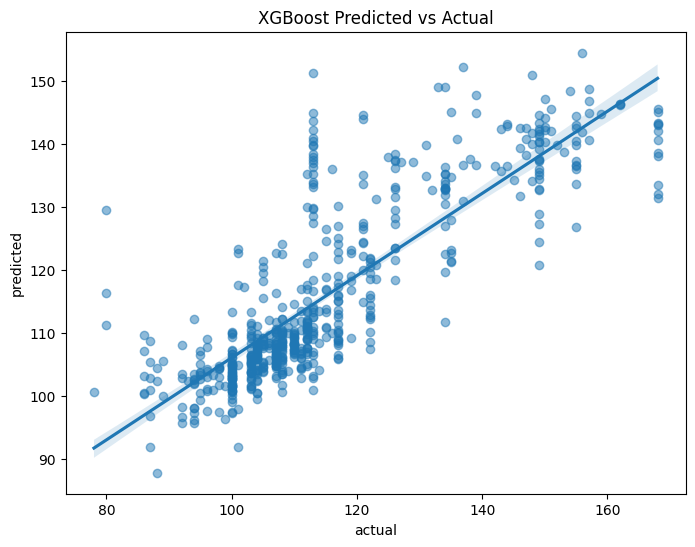

In [100]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout_m, y_holdout_m)

In [39]:
explainer = shap.Explainer(best_xgbr_model)

In [40]:
shap_values = explainer(pca_loc_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

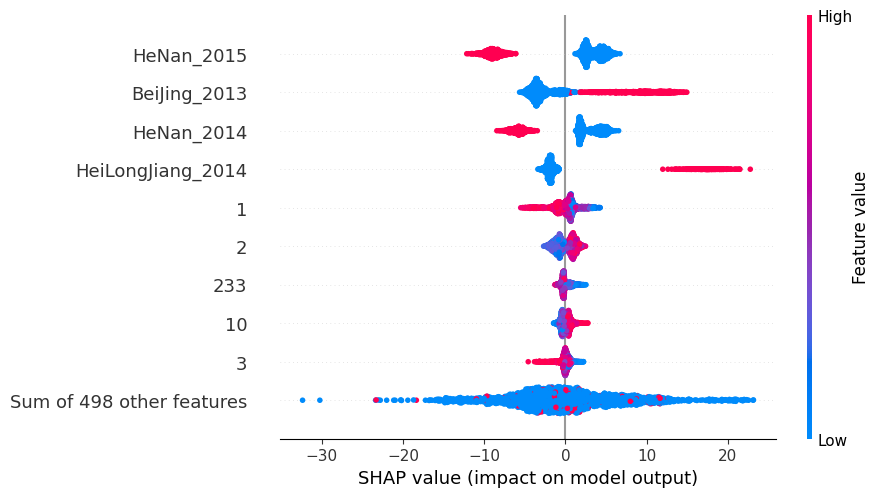

In [41]:
shap.plots.beeswarm(shap_values, show=False)

In [42]:
#### RF Models

In [43]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 50), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 500)])


In [80]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [ ]:
OrderedDict([('bootstrap', True), ('max_depth', 50), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 500)])

In [44]:
best_rfr_model = eval_k_fold(best_rfreg, pca_loc, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.8219482174957893
RMSE for dataset is:13.200396629745757& mean of this fold is 116.10204081632654
this is 11.369650814862755% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.7970235173274536
RMSE for dataset is:14.703149802807884& mean of this fold is 118.01632653061225
this is 12.458572669599265% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.6618864346144422
RMSE for dataset is:14.040798047135837& mean of this fold is 116.77142857142857
this is 12.024172538530813% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.5634599016030775
RMSE for dataset is:13.876661191218624& mean of this fold is 116.15918367346939
this is 11.946245447305115% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.7856044878897
RMSE

In [81]:
pca_loc = pca_loc.to_numpy()
y = y.to_numpy()
best_svr_model = eval_k_fold(best_svreg, pca_loc, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.2672212333048165
RMSE for dataset is:11.877318627807885& mean of this fold is 116.48571428571428
this is 10.19637360738965% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.2943455752281364
RMSE for dataset is:11.535664924692341& mean of this fold is 118.43265306122449
this is 9.740274009338377% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.3343920583446638
RMSE for dataset is:11.260740598649933& mean of this fold is 117.0326530612245
this is 9.621879282493055% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.22877575506381742
RMSE for dataset is:12.185292919971642& mean of this fold is 114.56734693877551
this is 10.635921355919528% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.1669034780787113
RMSE for 

In [102]:
#pickle.dump(best_rfr_model, open("pca_500_best_model_onlyloc_rfr_md.pickle.dat", "wb"))
best_rfr_model = pickle.load(open("../pickle_bestmodels/pca_500_best_model_onlyloc_rfr_md.pickle.dat", "rb"))

In [101]:
#pickle.dump(best_svr_model, open("pca_500_best_model_onlyloc_svr_md.pickle.dat", "wb"))
best_svr_model = pickle.load(open("../pickle_bestmodels/pca_500_best_model_onlyloc_svr_md.pickle.dat", "rb"))

R^2 Value of Holdout: 0.44
RMSE of Holdout: 13.75
Mean of Holdout: 115.12
This is 11.94% of the mean pheno data
0 117.0 128.738
1 115.0 125.846
2 100.0 104.51
3 107.0 111.609
4 168.0 124.962


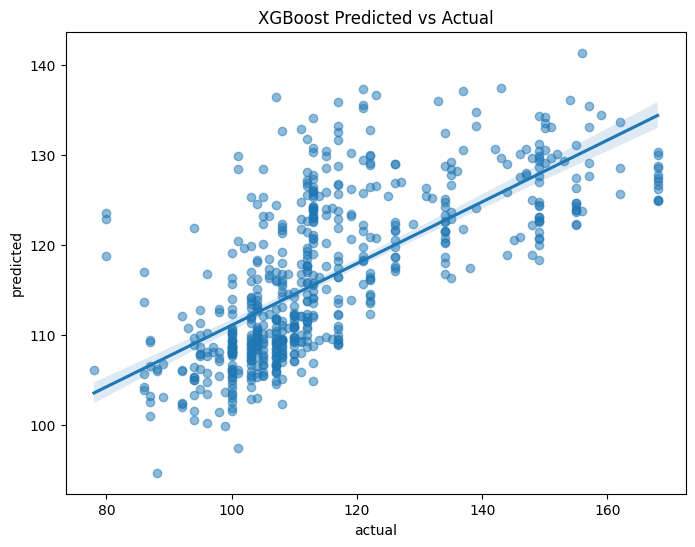

In [103]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout_m, y_holdout_m)

R^2 Value of Holdout: 0.60
RMSE of Holdout: 11.68
Mean of Holdout: 115.12
This is 10.15% of the mean pheno data
0 117.0 119.16819103911281
1 115.0 105.50079760057666
2 100.0 106.28690851899057
3 107.0 106.92369478597516
4 168.0 133.35664007464865


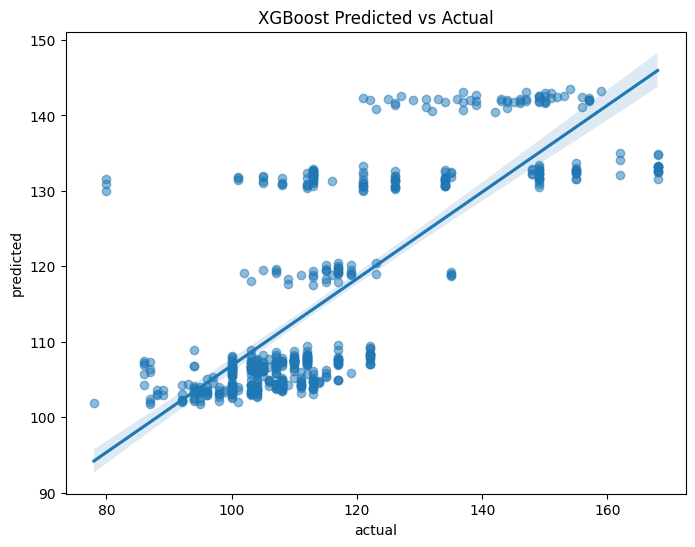

In [104]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout_m, y_holdout_m)

In [47]:
### Only PCs models

In [105]:
y = pca_full_train_m.iloc[:, 511:]
y.head()

,MD
Line,
s503,113.0
s2833,107.0
s1616,100.0
s833,103.0
s265,103.0


In [106]:
pca_only =  pca_full_train_m.iloc[:, :500]
pca_only.head()

,1,2,3,4,5,6,7,8,9,10,...,491,492,493,494,495,496,497,498,499,500
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,-0.023536,0.002960,0.004914,-0.011766,0.002108,-0.010215,0.018547,-0.021508,-0.024271,-0.011418
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,0.009285,0.032270,0.017829,0.003439,0.045344,-0.039668,-0.068647,0.005446,0.019524,0.054528
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,-0.009431,-0.004633,0.011966,0.005379,0.002594,0.003557,-0.000194,0.007665,-0.009861,-0.004266
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,-0.028132,-0.025362,0.037080,0.003618,-0.062027,-0.041410,0.019568,0.029024,0.018871,-0.007392
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,0.006723,-0.006412,-0.002909,-0.017702,0.030001,0.010845,0.052283,0.025662,0.057667,0.006056


In [107]:
pca_only_dupe =  pca_full_train_m.iloc[:, :500]
pca_only_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,491,492,493,494,495,496,497,498,499,500
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,-0.023536,0.002960,0.004914,-0.011766,0.002108,-0.010215,0.018547,-0.021508,-0.024271,-0.011418
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,0.009285,0.032270,0.017829,0.003439,0.045344,-0.039668,-0.068647,0.005446,0.019524,0.054528
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,-0.009431,-0.004633,0.011966,0.005379,0.002594,0.003557,-0.000194,0.007665,-0.009861,-0.004266
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,-0.028132,-0.025362,0.037080,0.003618,-0.062027,-0.041410,0.019568,0.029024,0.018871,-0.007392
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,0.006723,-0.006412,-0.002909,-0.017702,0.030001,0.010845,0.052283,0.025662,0.057667,0.006056


In [108]:
X_train, X_test, y_train, y_test = train_test_split(pca_only, y, test_size=0.1, random_state=42)

In [109]:
X_train.head()

,1,2,3,4,5,6,7,8,9,10,...,491,492,493,494,495,496,497,498,499,500
Line,,,,,,,,,,,,,,,,,,,,,
s863,0.020994,-0.017924,-0.000505,-0.028264,0.020462,-0.002946,-0.014835,0.009247,0.026842,-0.023992,...,-0.025948,0.015765,0.042118,-0.000574,-0.028207,0.002706,-0.007694,0.000279,0.036835,0.049242
s338,-0.009844,0.013358,0.020992,-0.036998,-0.037106,0.035101,-0.000918,0.013954,-0.010888,0.013694,...,-0.004094,0.023498,0.011770,0.019818,0.011220,0.035398,-0.009647,0.038940,0.014689,-0.005600
s582,-0.012012,0.057386,0.003213,-0.014743,0.008771,-0.007759,-0.014808,0.006685,-0.030697,-0.008176,...,0.001134,-0.010535,0.000809,0.006956,-0.024966,0.024035,-0.004496,0.002515,0.010260,-0.003147
s216,0.034190,-0.020503,0.017794,-0.005123,0.023337,-0.005070,-0.013410,-0.050472,-0.024485,0.007292,...,-0.004273,0.001248,-0.017221,-0.017414,0.018980,-0.006857,0.012261,0.008745,0.009889,0.000740
s473,0.003999,0.001473,0.015235,-0.027210,-0.046295,0.053714,-0.002097,0.001476,0.026196,-0.028050,...,0.044945,-0.010642,0.002675,0.011041,0.041390,0.015492,0.005476,0.020337,0.021462,0.006319


In [110]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [54]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.477217005407728), ('colsample_bytree', 0.7568163631993383), ('gamma', 6.150233082461141e-05), ('learning_rate', 0.07320410737810096), ('max_delta_step', 1), ('max_depth', 5), ('min_child_weight', 9), ('n_estimators', 128), ('reg_alpha', 7.921241006237601e-08), ('reg_lambda', 3.7199802270085394e-05), ('subsample', 0.5147260823434955)])


In [ ]:
OrderedDict([('colsample_bylevel', 0.477217005407728), ('colsample_bytree', 0.7568163631993383), ('gamma', 6.150233082461141e-05), ('learning_rate', 0.07320410737810096), ('max_delta_step', 1), ('max_depth', 5), ('min_child_weight', 9), ('n_estimators', 128), ('reg_alpha', 7.921241006237601e-08), ('reg_lambda', 3.7199802270085394e-05), ('subsample', 0.5147260823434955)])

In [55]:
pca_only = pca_only.to_numpy()
y = y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, pca_only, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -43.22681138118172
RMSE for dataset is:19.150625165945737& mean of this fold is 117.15510204081633
this is 16.346385972395588% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -53.51037633793234
RMSE for dataset is:20.10608188010551& mean of this fold is 117.42448979591836
this is 17.12256269118096% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -50.699165342160306
RMSE for dataset is:19.02966874580282& mean of this fold is 116.34285714285714
this is 16.35654238956529% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -43.334653965402474
RMSE for dataset is:18.19064819718412& mean of this fold is 115.7673469387755
this is 15.713107951592251% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -70.59426526223724
RMSE for d

In [111]:
#pickle.dump(best_xgbr_model, open("pca_500_best_model_onlypcs_xgbr_md.pickle.dat", "wb"))

best_xgbr_model = pickle.load(open("../pickle_bestmodels/pca_500_best_model_onlypcs_xgbr_md.pickle.dat", "rb"))

In [112]:
pca_full_holdout_m.head()

,1,2,3,4,5,6,7,8,9,10,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,0.005044,-0.006670,...,94.8000,1.40000,0,0,0,0,1,1,0,117.0
s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,-0.028440,0.038526,...,120.8000,2.80000,0,0,1,0,0,0,1,115.0
s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,0.023780,0.003327,...,60.4000,1.60000,0,1,0,0,0,1,0,100.0
s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,-0.017821,-0.049911,...,63.0000,1.80000,0,1,0,0,0,0,1,107.0
s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,0.045854,-0.018372,...,97.1667,4.33333,1,0,0,0,0,0,1,168.0


In [113]:
X_holdout_m = pca_full_holdout_m.iloc[:, :511]
X_holdout_m.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,0.005044,-0.006670,...,4.96600,94.8000,1.40000,0,0,0,0,1,1,0
s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,-0.028440,0.038526,...,6.11333,120.8000,2.80000,0,0,1,0,0,0,1
s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,0.023780,0.003327,...,4.19333,60.4000,1.60000,0,1,0,0,0,1,0
s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,-0.017821,-0.049911,...,7.30667,63.0000,1.80000,0,1,0,0,0,0,1
s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,0.045854,-0.018372,...,6.93333,97.1667,4.33333,1,0,0,0,0,0,1


In [114]:
y_holdout_m = pca_full_holdout_m.iloc[:, 511:]
y_holdout_m.head()

,MD
Line,
s2692,117.0
s131,115.0
s272,100.0
s344,107.0
s324,168.0


In [115]:
# Ensure both training and holdout datasets have the same columns
pca_only_dupe, X_holdout_m = pca_only_dupe.align(X_holdout_m, join='inner', axis=1)

In [116]:
X_holdout_m.head()

,1,2,3,4,5,6,7,8,9,10,...,491,492,493,494,495,496,497,498,499,500
Line,,,,,,,,,,,,,,,,,,,,,
s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,0.005044,-0.006670,...,0.004731,0.002866,0.033824,0.019988,0.008449,-0.017799,0.031572,-0.004834,0.016250,-0.003984
s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,-0.028440,0.038526,...,0.044251,0.039777,0.005735,-0.004677,0.009932,0.002686,-0.025414,-0.005636,-0.008737,0.009723
s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,0.023780,0.003327,...,-0.002124,-0.013742,-0.005291,-0.002630,0.006311,0.009682,0.003305,0.000757,-0.003276,0.000108
s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,-0.017821,-0.049911,...,-0.006077,0.001724,0.001140,0.006521,-0.009520,-0.007994,-0.003575,-0.013631,-0.001659,0.012328
s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,0.045854,-0.018372,...,0.030985,0.016392,0.018242,-0.000687,0.006557,0.000821,0.003615,0.030966,-0.004702,-0.020557


In [117]:
X_holdout_m = X_holdout_m.to_numpy()
y_holdout_m = y_holdout_m.to_numpy()

R^2 Value of Holdout: 0.01
RMSE of Holdout: 18.35
Mean of Holdout: 115.12
This is 15.94% of the mean pheno data
0 117.0 118.37173
1 115.0 122.33879
2 100.0 115.00434
3 107.0 114.00257
4 168.0 116.78217


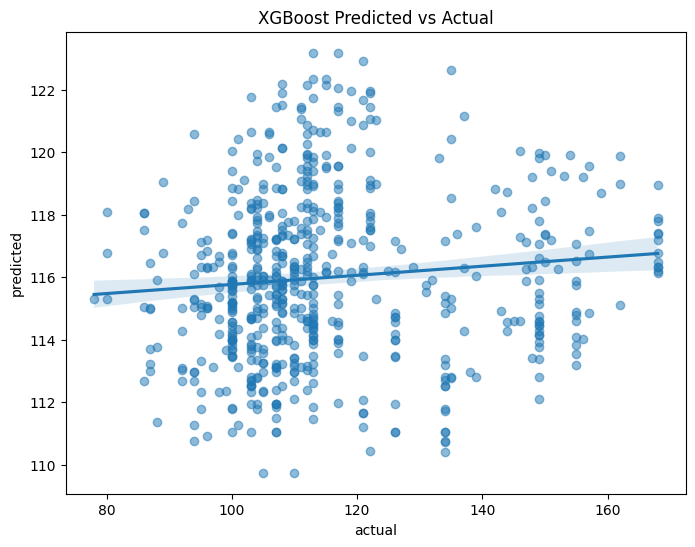

In [118]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout_m, y_holdout_m)

In [64]:
explainer = shap.Explainer(best_xgbr_model)

In [68]:
shap_values = explainer(pca_only_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

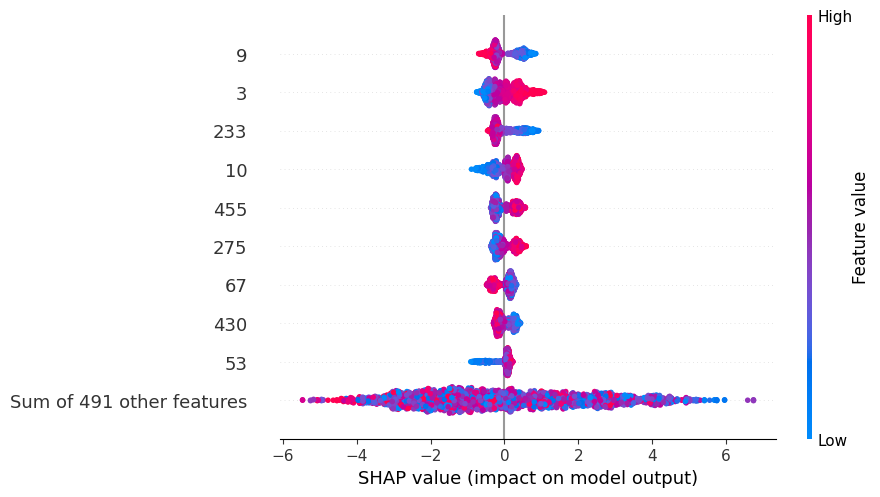

In [69]:
shap.plots.beeswarm(shap_values, show=False)

<Figure size 2000x2000 with 0 Axes>

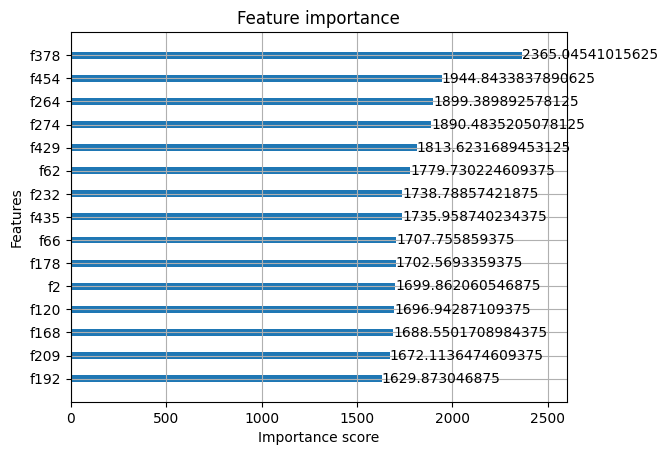

In [70]:
from xgboost import plot_importance
from matplotlib import pyplot
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

#### RF Models

In [71]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 3), ('max_features', 'sqrt'), ('max_samples', 0.5), ('min_samples_leaf', 10), ('min_samples_split', 13), ('n_estimators', 460)])


In [96]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 3), ('kernel', 'rbf')])


In [ ]:
OrderedDict([('bootstrap', True), ('max_depth', 3), ('max_features', 'sqrt'), ('max_samples', 0.5), ('min_samples_leaf', 10), ('min_samples_split', 13), ('n_estimators', 460)])

In [72]:
best_rfr_model = eval_k_fold(best_rfreg, pca_only, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -163.3543559587296
RMSE for dataset is:18.109365948295395& mean of this fold is 116.61632653061224
this is 15.52901423587684% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -155.11306594942528
RMSE for dataset is:16.93610171671642& mean of this fold is 113.91428571428571
this is 14.867408078381608% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -216.12003325662903
RMSE for dataset is:19.25325472965071& mean of this fold is 116.3
this is 16.554819200043603% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -184.89803733052466
RMSE for dataset is:19.144690173513784& mean of this fold is 116.25714285714285
this is 16.467538856549087% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -239.21275467703248
RMSE for dataset i

In [97]:
pca_only = pca_only.to_numpy()
y = y.to_numpy()
best_svr_model = eval_k_fold(best_svreg, pca_only, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -216.2952429134712
RMSE for dataset is:19.90925525547162& mean of this fold is 117.51836734693877
this is 16.941398782962445% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -255.61766099872364
RMSE for dataset is:21.12182048364705& mean of this fold is 117.24897959183673
this is 18.014502605630884% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -157.15247643567488
RMSE for dataset is:17.53551363640195& mean of this fold is 115.2
this is 15.221800031598917% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -151.98738483335194
RMSE for dataset is:18.037557591617215& mean of this fold is 115.0469387755102
this is 15.678433327820828% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -207.64089949243703
RMSE for dataset is

In [119]:
#pickle.dump(best_rfr_model, open("pca_500_best_model_onlypcs_rfr_md.pickle.dat", "wb"))
best_rfr_model = pickle.load(open("../pickle_bestmodels/pca_500_best_model_onlypcs_rfr_md.pickle.dat", "rb"))

In [120]:
#pickle.dump(best_svr_model, open("pca_500_best_model_onlypcs_svr_md.pickle.dat", "wb"))
best_svr_model = pickle.load(open("../pickle_bestmodels/pca_500_best_model_onlypcs_svr_md.pickle.dat", "rb"))

R^2 Value of Holdout: -0.00
RMSE of Holdout: 18.42
Mean of Holdout: 115.12
This is 16.00% of the mean pheno data
0 117.0 115.44869786928521
1 115.0 119.79321621664816
2 100.0 114.94907726335342
3 107.0 114.43989380831982
4 168.0 115.5870458206456


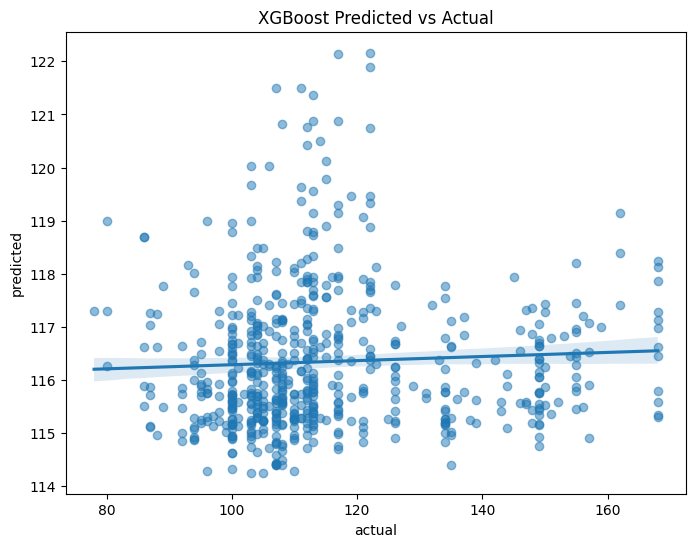

In [121]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout_m, y_holdout_m)

R^2 Value of Holdout: -0.03
RMSE of Holdout: 18.63
Mean of Holdout: 115.12
This is 16.18% of the mean pheno data
0 117.0 109.76446899461271
1 115.0 115.56727383197972
2 100.0 109.69212730420547
3 107.0 107.72748348629887
4 168.0 111.48474290556972


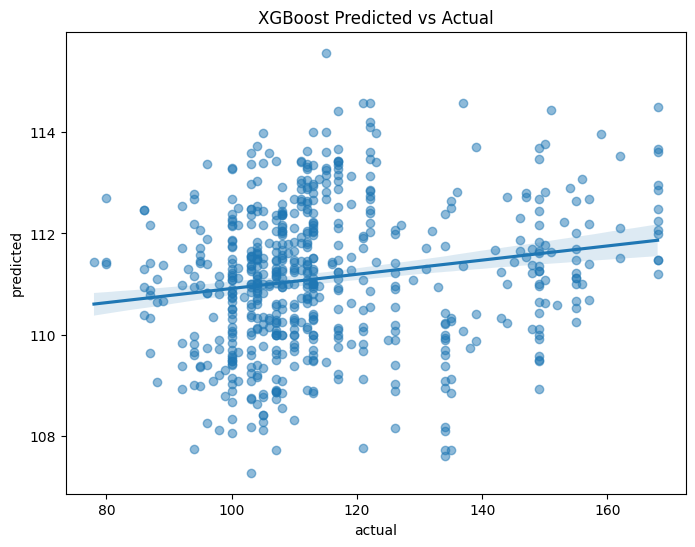

In [122]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout_m, y_holdout_m)